# 중앙대·숭실대 통학로 규정

두 학교를 같은 규칙으로 비교하기 위한 실행 결과 노트북이다.

1. **대학가 영역**: 카카오 학교 대표점 중심 반경 800m
2. **학교 범위**: OSM 캠퍼스 폴리곤
3. **출입문**: 공식 명칭을 확인한 카카오 입출구 좌표
4. **후보 통학망**: OSM 학교 밖 보행 엣지
5. **최종 통학 구간**: 800m 임의점을 OSM 노드에 스냅한 뒤 TMAP 실제 경로에서 관측된 OSM 엣지
5. **최단경로 중첩수**: 각 출발 노드의 최단 통학경로가 엣지에서 겹치는 횟수(실제 통행량은 아님)

거리·면적 계산은 EPSG:5186, 지도와 저장 결과는 EPSG:4326을 사용한다. 아래 셀에는 기존 실행 출력과 지도가 포함되어 있다.

# A. 숭실대학교

카카오 `숭실대학교` 대표점, 반경 800m, OSM 캠퍼스 폴리곤, 카카오 출입문 5곳을 사용한다.

In [2]:
import os
import sys
from pathlib import Path

import folium
import geopandas as gpd
import pandas as pd
import requests
from dotenv import load_dotenv
from IPython.display import display
from shapely.geometry import Point

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data').exists():
    # Jupyter를 상위 폴더에서 실행한 경우를 대비한 보정
    PROJECT_DIR = PROJECT_DIR / 'DartB_TOYPROJECT'
sys.path.insert(0, str(PROJECT_DIR))
load_dotenv(PROJECT_DIR / '.env')

import soongsil_config as cfg  # 기준점·반경 (1단계 결정값)

DATA_DIR = PROJECT_DIR / 'data'
PROJ_CRS = 'EPSG:5186'  # 중부원점 TM: 미터 단위 거리·면적 계산용

def dist_m(lat1, lon1, lat2, lon2):
    """WGS84 두 점 사이 거리(m). 투영 좌표계로 바꿔서 잰다."""
    s = gpd.GeoSeries([Point(lon1, lat1), Point(lon2, lat2)], crs='EPSG:4326').to_crs(PROJ_CRS)
    return s.iloc[0].distance(s.iloc[1])

print(f'기준점 (config): lat={cfg.CENTER_LAT:.6f}, lon={cfg.CENTER_LON:.6f}, 반경 {cfg.RADIUS_M}m')

기준점 (config): lat=37.495853, lon=126.957818, 반경 800m


## 1. 대학가 규정

### 1-1. 기준점 확인 — 카카오 로컬 API로 다시 조회

`soongsil_config.py`의 좌표가 지금도 카카오 "숭실대학교" 검색 1순위와 같은지 확인한다. (API 키가 없으면 건너뛴다.)

In [3]:
def kakao_top(query):
    headers = {'Authorization': f"KakaoAK {os.environ['KAKAO_REST_API_KEY']}"}
    r = requests.get(
        'https://dapi.kakao.com/v2/local/search/keyword.json',
        headers=headers, params={'query': query, 'size': 1}, timeout=15,
    )
    r.raise_for_status()
    d = r.json()['documents'][0]
    return d['place_name'], d['category_name'], d['road_address_name'], float(d['y']), float(d['x'])

try:
    name, category, addr, lat, lon = kakao_top('숭실대학교')
    delta = dist_m(cfg.CENTER_LAT, cfg.CENTER_LON, lat, lon)
    print(f'카카오 검색 "숭실대학교" 1순위: {name} | {category} | {addr}')
    print(f'  lat={lat:.6f}, lon={lon:.6f}')
    print(f'  config 좌표와의 차이: {delta:.2f}m', '(일치)' if delta < 1 else '(!) 카카오 쪽 값이 바뀜 - config 확인 필요')
except KeyError:
    print('KAKAO_REST_API_KEY가 없어 API 재조회를 건너뜀 (config 값 사용)')

카카오 검색 "숭실대학교" 1순위: 숭실대학교 | 교육,학문 > 학교 > 대학교 | 서울 동작구 상도로 369
  lat=37.495853, lon=126.957818
  config 좌표와의 차이: 0.00m (일치)


### 1-2. 후보 지점 비교 (정문·출입구 vs 대표점)

카카오는 "숭실대학교"(캠퍼스 대표점)와 "숭실대학교 정문"을 서로 다른 지점으로 돌려준다. `compare_univ_center.py`가 만든 후보 표에서, **선택한 기준점(대표점)으로부터 각 지점이 얼마나 떨어져 있는지** 본다.

In [4]:
cand = pd.read_csv(DATA_DIR / 'soongsil_center_candidates.csv')
cand['기준점과의거리_m'] = [round(dist_m(cfg.CENTER_LAT, cfg.CENTER_LON, la, lo)) for la, lo in zip(cand['lat'], cand['lon'])]
cand['반경800m_안'] = cand['기준점과의거리_m'] <= cfg.RADIUS_M
display(cand[['후보', '장소명', 'lat', 'lon', '기준점과의거리_m', '반경800m_안']].sort_values('기준점과의거리_m'))

,후보,장소명,lat,lon,기준점과의거리_m,반경800m_안
0,KAKAO 대표점,숭실대학교,37.495853,126.957818,0,True
6,OSM 중문,OSM 중문,37.495491,126.956716,105,True
7,OSM 남문,OSM 남문,37.495182,126.958933,124,True
2,KAKAO 후문,숭실대학교 후문,37.497512,126.958026,185,True
1,KAKAO 정문,숭실대학교 정문,37.495972,126.954504,293,True
4,OSM 정문,OSM 정문,37.495981,126.954381,304,True
5,OSM 북문,OSM 북문,37.497927,126.955538,306,True
3,KAKAO 숭실대입구역,숭실대입구역 7호선,37.496317,126.953622,375,True


### 1-3. 학교 범위 규정 — 카카오 문 좌표 + OSM 캠퍼스 폴리곤

- **출입구**: 카카오 API 키워드 검색 `숭실대학교 <문 이름>` 결과 (정문·후문·북문·중문·남문). 조회 결과는 `data/soongsil_kakao_gates.csv`에 저장해 API 키가 없어도 다시 실행할 수 있게 한다.
- **학교 범위**: OSM 캠퍼스 폴리곤 (`data/soongsil_campus_polygon.geojson`). 학교 범위를 원(반경)으로 근사하지 않는다.
- **대학가 영역**: 기준점 반경 800m 원 (팀 합의). 통학로는 이 원 안에서 학교 폴리곤을 뺀 나머지에서 찾는다.

아래 표는 카카오 문 좌표가 OSM 폴리곤 경계와 얼마나 어긋나는지 보여준다. 경계에서 25m 넘게 벗어난 문이 있으면 문 좌표를 그대로 쓰기 어렵다.

In [5]:
import viz_campus_definition as viz  # 캠퍼스 폴리곤·카카오 문 조회·지표 함수 재사용

GATE_CACHE = DATA_DIR / 'soongsil_kakao_gates.csv'
try:
    kakao_gates_ll = viz.load_kakao_gates()  # {문 이름: (lat, lon)}
    pd.DataFrame([{'문': n, 'lat': la, 'lon': lo} for n, (la, lo) in kakao_gates_ll.items()]).to_csv(GATE_CACHE, index=False, encoding='utf-8-sig')
    print('카카오 API로 문 좌표 조회 -> 저장:', GATE_CACHE.name)
except KeyError:
    cache = pd.read_csv(GATE_CACHE)
    kakao_gates_ll = {r['문']: (r['lat'], r['lon']) for _, r in cache.iterrows()}
    print('KAKAO_REST_API_KEY가 없어 저장된 문 좌표를 사용:', GATE_CACHE.name)

campus = viz.to_proj(viz.load_campus_polygon())                       # 학교 범위 (EPSG:5186)
kakao_gates = {n: viz.to_proj(Point(lo, la)) for n, (la, lo) in kakao_gates_ll.items()}
center_pt = gpd.GeoSeries([Point(cfg.CENTER_LON, cfg.CENTER_LAT)], crs='EPSG:4326').to_crs(PROJ_CRS).iloc[0]
circle_proj = center_pt.buffer(cfg.RADIUS_M)                          # 대학가 영역 (반경 800m)
circle_ll = viz.to_ll(circle_proj)
campus_ll = viz.to_ll(campus)

gate_table = pd.DataFrame([{
    '문': n, 'lat': kakao_gates_ll[n][0], 'lon': kakao_gates_ll[n][1],
    '폴리곤': '안' if campus.contains(p) else '밖',
    '경계까지_m': round(campus.boundary.distance(p), 1),
    '기준점과의거리_m': round(center_pt.distance(p)),
} for n, p in kakao_gates.items()])
gate_table['경계25m_이내'] = gate_table['경계까지_m'] <= 25
display(gate_table.sort_values('경계까지_m'))

print(f'캠퍼스 폴리곤: {campus.area / 1e4:.1f}ha (조각 {len(campus.geoms) if campus.geom_type == "MultiPolygon" else 1}개)')
print(f'대학가 영역(반경 {cfg.RADIUS_M}m 원): {circle_proj.area / 1e6:.2f}km², 그중 학교 폴리곤 {campus.intersection(circle_proj).area / circle_proj.area * 100:.1f}%')
print('캠퍼스 폴리곤이 800m 원 안에 전부 들어가는가:', '예' if circle_proj.contains(campus) else '아니오 (일부가 원 밖)')

m1 = folium.Map(location=[cfg.CENTER_LAT, cfg.CENTER_LON], zoom_start=15, tiles='OpenStreetMap')
folium.GeoJson(circle_ll.__geo_interface__, style_function=lambda _: {'color': '#2563eb', 'weight': 2, 'fillOpacity': 0.03},
               tooltip=f'대학가 영역 (반경 {cfg.RADIUS_M}m)').add_to(m1)
folium.GeoJson(campus_ll.__geo_interface__, style_function=lambda _: {'color': '#1d4ed8', 'weight': 2, 'fillColor': '#60a5fa', 'fillOpacity': 0.3},
               tooltip='학교 범위 (OSM 캠퍼스 폴리곤)').add_to(m1)
for _, r in gate_table.iterrows():
    folium.CircleMarker(
        [r['lat'], r['lon']], radius=6, color='#dc2626', fill=True, fill_opacity=0.9,
        tooltip=f"카카오 {r['문']} | 폴리곤 {r['폴리곤']}, 경계까지 {r['경계까지_m']}m",
    ).add_to(m1)
folium.Marker([cfg.CENTER_LAT, cfg.CENTER_LON], tooltip='기준점: 카카오 "숭실대학교"', icon=folium.Icon(color='blue')).add_to(m1)
m1

카카오 API로 문 좌표 조회 -> 저장: soongsil_kakao_gates.csv


,문,lat,lon,폴리곤,경계까지_m,기준점과의거리_m,경계25m_이내
4,중문,37.495428,126.956726,밖,0.9,107,True
1,후문,37.497512,126.958026,밖,3.2,185,True
3,북문,37.497888,126.955571,안,4.7,301,True
2,남문,37.495262,126.958888,안,16.5,115,True
0,정문,37.495972,126.954504,안,20.8,293,True


캠퍼스 폴리곤: 12.5ha (조각 3개)
대학가 영역(반경 800m 원): 2.01km², 그중 학교 폴리곤 6.2%
캠퍼스 폴리곤이 800m 원 안에 전부 들어가는가: 예


### 1-4. 학교 범위 규정 방식 비교 — 단순 반경 vs 폴리곤 (문 좌표는 카카오로 동일)

출입구는 두 방식 모두 위 1-3의 카카오 문 좌표를 쓰고, **학교 범위를 나타내는 방식만** 다르게 한다.

- **반경 방식**: 카카오 문마다 반경 R의 원을 씌워 합친 영역을 학교로 본다. R은 100m와, 캠퍼스의 99%를 덮는 최소 반경 두 가지를 본다.
- **폴리곤 방식**: OSM 캠퍼스 폴리곤을 학교로 본다.

기준(정답 대용)은 OSM 폴리곤이다. 공식 경계 데이터가 아니므로 폴리곤 방식의 지표는 항상 100%/0으로 나오며, 이는 "정답과 같다"가 아니라 "기준 자체"라는 뜻이다. 보행망은 OSM 보행망이다.

| 지표 | 의미 |
|---|---|
| 캠퍼스 커버율 | 기준 폴리곤 중 학교로 잡힌 비율 |
| 학교 밖 초과 면적 | 학교가 아닌데 학교로 잡힌 면적 |
| 학교 밖인데 제외되는 보행망 | 학교 범위에 잘못 포함되어 통학로 후보에서 빠지는 길이 |
| 학교 안인데 통학로로 남는 보행망 | 학교 범위에서 빠져 학교 안 길이 통학로로 잘못 남는 길이 |

,캠퍼스 커버율(%),학교 밖 초과 면적(ha),학교 밖인데 제외되는 보행망(m),학교 안인데 통학로로 남는 보행망(m)
반경 100m,62.7,7.8,3575.7,1100.2
반경 162m (캠퍼스 99% 덮는 최소 반경),99.0,19.6,6644.6,21.4
폴리곤 (OSM 캠퍼스),100.0,0.0,0.0,0.0


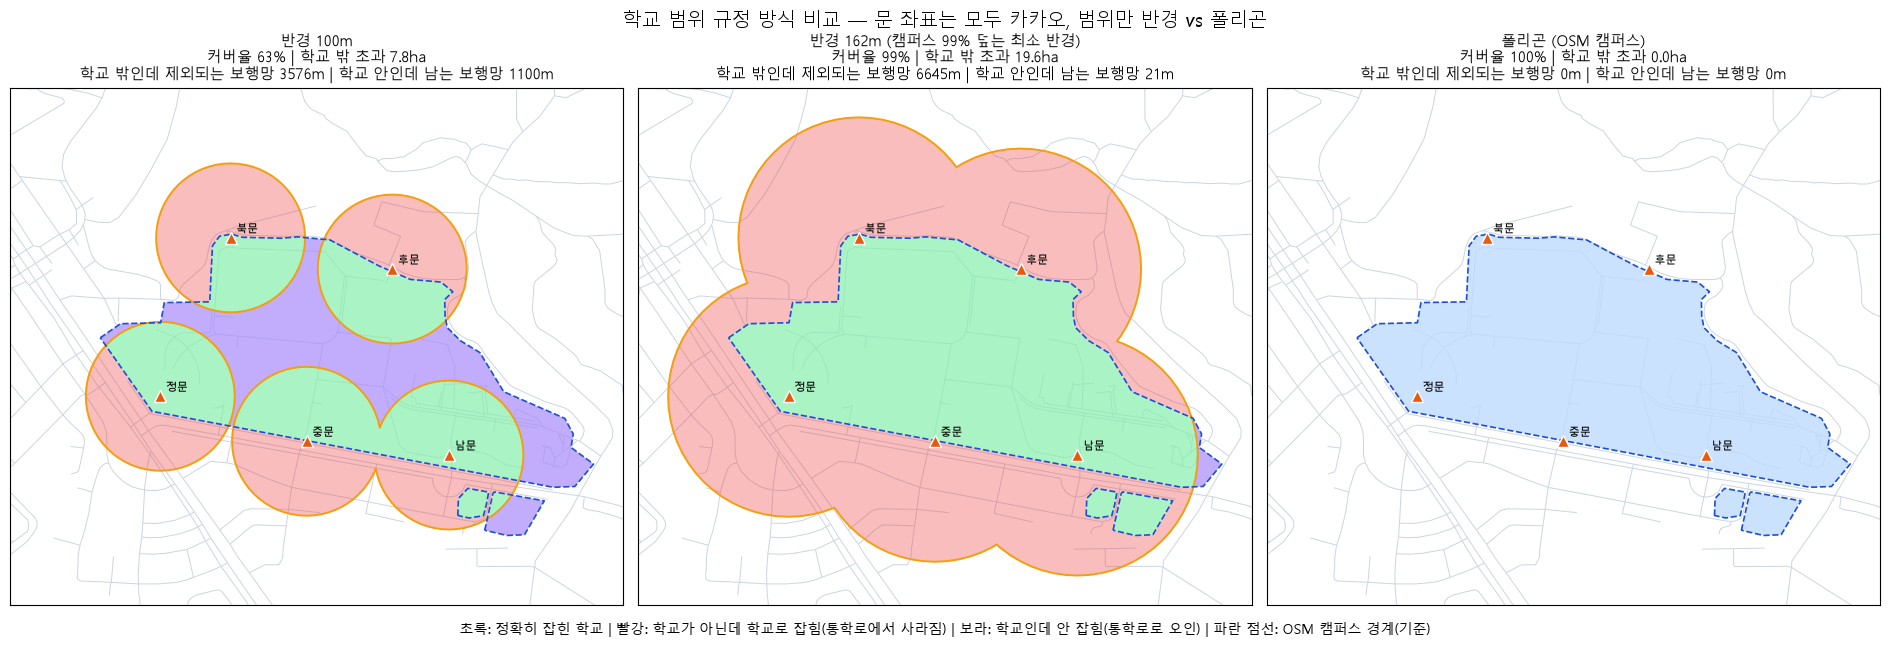

In [6]:
import matplotlib.pyplot as plt
from shapely.ops import unary_union

edges = viz.load_walk_edges()  # OSM 보행망 (EPSG:5186, 800m 원보다 150m 넓게)
gate_pts = list(kakao_gates.values())
r_cover = viz.cover_radius(gate_pts, campus)
regions = {
    '반경 100m': viz.union_of_circles(gate_pts, 100),
    f'반경 {r_cover:.0f}m (캠퍼스 99% 덮는 최소 반경)': viz.union_of_circles(gate_pts, r_cover),
    '폴리곤 (OSM 캠퍼스)': campus,
}
compare = pd.DataFrame({k: viz.evaluate(v, campus, edges) for k, v in regions.items()}).T.round(1)
display(compare)

bx0, by0, bx1, by1 = unary_union(list(regions.values())).bounds
extent = (bx0 - 40, by0 - 40, bx1 + 40, by1 + 40)  # 세 패널을 같은 축척·범위로

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (name, region) in zip(axes, regions.items()):
    r = compare.loc[name]
    title = (f"{name}\n커버율 {r['캠퍼스 커버율(%)']:.0f}% | 학교 밖 초과 {r['학교 밖 초과 면적(ha)']:.1f}ha\n"
             f"학교 밖인데 제외되는 보행망 {r['학교 밖인데 제외되는 보행망(m)']:.0f}m | 학교 안인데 남는 보행망 {r['학교 안인데 통학로로 남는 보행망(m)']:.0f}m")
    if region is campus:
        viz.draw_map(ax, title, edges, campus, extent, gates=kakao_gates, gate_color='#ea580c')
    else:
        viz.draw_map(ax, title, edges, campus, extent, region, gates=kakao_gates, gate_color='#ea580c')
fig.suptitle('학교 범위 규정 방식 비교 — 문 좌표는 모두 카카오, 범위만 반경 vs 폴리곤', fontsize=14)
fig.text(0.5, 0.02, '초록: 정확히 잡힌 학교 | 빨강: 학교가 아닌데 학교로 잡힘(통학로에서 사라짐) | 보라: 학교인데 안 잡힘(통학로로 오인) | 파란 점선: OSM 캠퍼스 경계(기준)',
         ha='center', fontsize=10)
plt.tight_layout(rect=(0, 0.04, 1, 0.94))
plt.show()

### 1단계 정리

- 학교 범위 = OSM 캠퍼스 폴리곤, 출입구 = 카카오 문 좌표로 규정한다. 반경 방식은 커버율을 올릴수록 학교 밖 길이 함께 제외되어(1-4 참고) 채택하지 않는다.
- 기준점 = 카카오맵 "숭실대학교" 검색 지점(캠퍼스 대표점), 반경 = 800m로 확정.
- 대표점은 정문에서 동쪽으로 약 300m 떨어져 있어, 원의 서쪽 경계가 정문 앞 상권 바로 바깥까지만 닿는다. (위 지도·표 참고)
- **팀 확인 필요:** 중앙대는 기존에 정문(OSM) 기준으로 분석했다. 비교 대시보드에서 기준점 규칙(중앙대=정문 / 숭실대=대표점)이 다르면 비교가 어긋날 수 있다.
- 다음: 2단계에서 이 원 안의 보행망을 노드·엣지로 만들고, 통학로를 어떻게 규정할지(원 안 전체 vs 출발점→출입구 경로, 직선 vs 보행 800m) 정한다.


---
## 2. 구간·거리 규정

**구간 정의** (구현: `soongsil_network.py`)

- 구간의 최소 단위는 OSM 보행망의 **엣지**(교차점~교차점)다. 두 지점 사이 구간은 최단경로로 계산한다.
- 800m 원(직선) 안에서 **학교 폴리곤 안쪽 엣지**(엣지 길이의 50% 이상이 폴리곤 안)를 지운다. 남은 그래프가 학교 밖 보행망이다.
- **문**(카카오 5개)은 남은 그래프의 가장 가까운 노드에 **가상 연결선**(직선거리)으로 붙인다. 연결선이 25m를 넘으면 경고한다.
- 문마다 보행 최단경로를 계산해, 학교 밖 모든 노드가 **보행거리로 가장 가까운 문**과 그 거리를 갖게 한다.
- 엣지는 양 끝 노드의 가장 가까운 문이 같으면 그 문 소속, 다르면 `경계`. **최단경로 중첩수** = 원 안 노드들이 가장 가까운 문으로 가는 최단경로가 그 엣지에서 겹치는 횟수. 실제 통행량이 아니라, 모든 노드를 같은 비중으로 보고 최단경로로 걷는다고 가정한 값이다.
- 원 밖 150m 여유 구간은 우회 경로 계산에만 쓰고, 원 안 결과 집계에서는 뺀다.

**규칙 변경 기록**: 앞서 "출입구 25m 안 엣지는 지우지 않는다"로 정했으나, 이 조건에 걸린 엣지 중 104~165m나 학교 안으로 뻗은 도로가 있어 통째로 남기면 학교 내부 도로가 통학로에 섞인다. 대신 가상 연결선으로 문이 끊기지 않게 했다.

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import soongsil_network as sn

res = sn.run()
campus, circle, gates = res['campus'], res['circle'], res['gates']
nodes, edges, removed = res['nodes'], res['edges'], res['removed']
G_full, G_cut = res['G_full'], res['G_cut']

print(f"OSM 보행망(원+150m): 노드 {len(G_full):,}, 엣지 {G_full.number_of_edges():,}")
print(f"학교 내부 엣지 제거: {len(removed)}개, {removed.geometry.length.sum():,.0f}m -> 남은 그래프 노드 {len(G_cut):,}, 엣지 {G_cut.number_of_edges():,}")
print(f"연결 요소 수: {nx.number_connected_components(G_cut)}  (1이면 학교 밖 보행망이 한 덩어리로 이어짐)")
origins = nodes[nodes['출발노드']]
print(f"출발 노드(원 안·학교 밖): {len(origins)}개, 문에 도달 못 하는 노드: {origins['가까운_문'].isna().sum()}개")
display(res['gate_table'])

OSM 보행망(원+150m): 노드 797, 엣지 1,122
학교 내부 엣지 제거: 71개, 3,109m -> 남은 그래프 노드 738, 엣지 1,051
연결 요소 수: 1  (1이면 학교 밖 보행망이 한 덩어리로 이어짐)
출발 노드(원 안·학교 밖): 400개, 문에 도달 못 하는 노드: 0개


,문,연결_노드,연결선_m,경고
0,정문,11413637697,23.5,False
1,후문,4686503139,2.7,False
2,남문,13149390531,21.4,False
3,북문,2825714913,11.1,False
4,중문,13149390530,4.2,False


-> '연결요소 수 1 ' -> 학교 밖의 구간들이 하나로 묶임을 의미. -> 이를 통해 학교 밖의 모든 구간들을 통학로로 규정할 수가 있는 것임. 

In [8]:
ein = edges[edges['원_안'] & (edges['highway'] != 'gate_connector')]
by_gate = origins.groupby('가까운_문').agg(
    노드수=('node', 'size'), 평균_보행거리_m=('문까지_보행_m', 'mean'), 최대_보행거리_m=('문까지_보행_m', 'max')).round(0)
by_gate['엣지수(원 안)'] = ein.groupby('소속_문').size()
by_gate['엣지길이_km'] = (ein.assign(l=ein.geometry.length).groupby('소속_문')['l'].sum() / 1000).round(2)
display(by_gate.sort_values('노드수', ascending=False))
print('경계 엣지(양 끝이 서로 다른 문 소속):', int((ein['소속_문'] == '경계').sum()), '개')

mis = origins['가까운_문'] != origins['직선_최근접_문']
print(f"직선으로 가장 가까운 문과 보행으로 가장 가까운 문이 다른 노드: {mis.sum()}개 / {len(origins)}개 ({mis.mean() * 100:.1f}%)")
close = origins['1-2순위_차이_m'] < 50
print(f"1순위와 2순위 문의 보행거리 차이가 50m 미만인 노드(어느 문이든 비슷한 곳): {close.sum()}개 ({close.mean() * 100:.1f}%)")

,노드수,평균_보행거리_m,최대_보행거리_m,엣지수(원 안),엣지길이_km
가까운_문,,,,,
정문,171,457.0,1384.0,250,13.44
중문,78,594.0,915.0,102,4.75
남문,76,611.0,1564.0,100,8.12
북문,47,470.0,795.0,67,3.98
후문,28,545.0,972.0,34,3.54


경계 엣지(양 끝이 서로 다른 문 소속): 34 개
직선으로 가장 가까운 문과 보행으로 가장 가까운 문이 다른 노드: 60개 / 400개 (15.0%)
1순위와 2순위 문의 보행거리 차이가 50m 미만인 노드(어느 문이든 비슷한 곳): 51개 (12.8%)


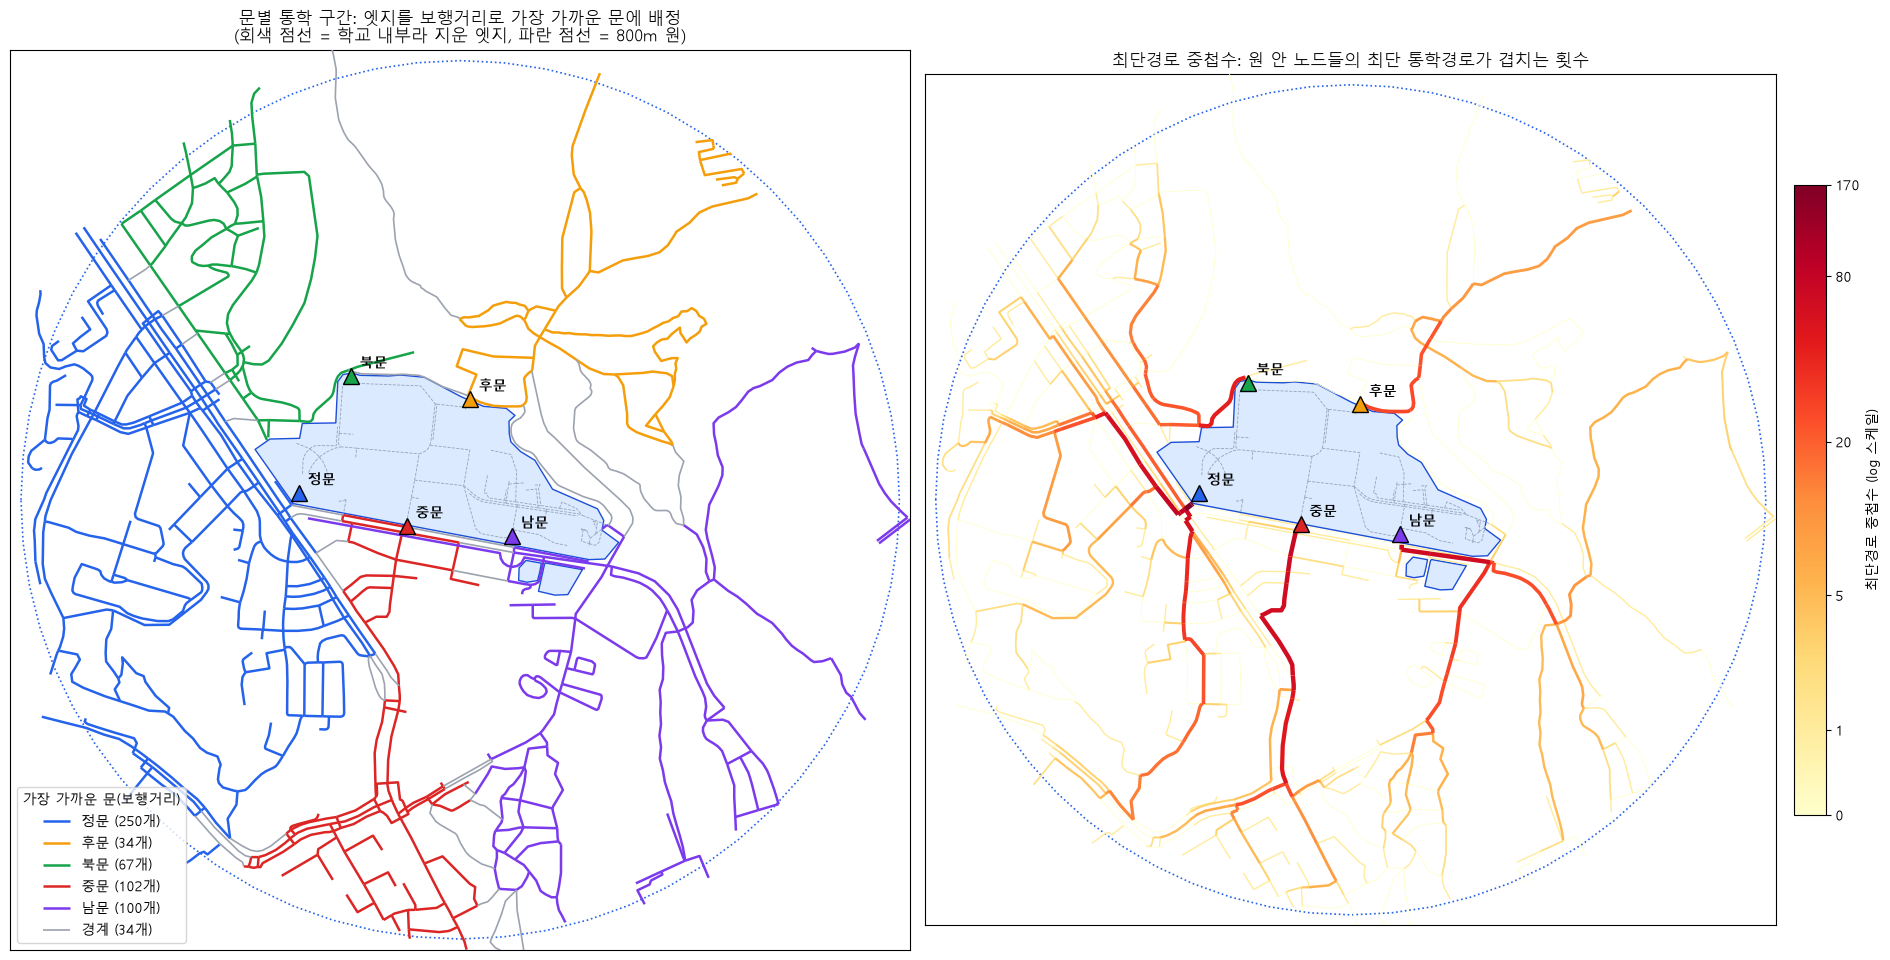

In [9]:
GATE_COLORS = {'정문': '#2563eb', '후문': '#f59e0b', '북문': '#16a34a', '중문': '#dc2626', '남문': '#7c3aed', '경계': '#9ca3af'}
minx, miny, maxx, maxy = circle.bounds

fig, axes = plt.subplots(1, 2, figsize=(19, 9.5))
for ax in axes:
    gpd.GeoSeries([campus]).plot(ax=ax, color='#dbeafe', edgecolor='#1d4ed8', linewidth=1, zorder=1)
    removed.plot(ax=ax, color='#94a3b8', linewidth=0.6, linestyle='--', zorder=2)
    gpd.GeoSeries([circle]).boundary.plot(ax=ax, color='#2563eb', linestyle=':', linewidth=1.2, zorder=2)
    for name, p in gates.items():
        ax.plot(p.x, p.y, '^', ms=11, color=GATE_COLORS[name], markeredgecolor='black', zorder=6)
        ax.annotate(name, (p.x, p.y), fontsize=10, fontweight='bold', xytext=(6, 6), textcoords='offset points', zorder=7)
    ax.set_xlim(minx - 20, maxx + 20); ax.set_ylim(miny - 20, maxy + 20)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

for name in ['정문', '후문', '북문', '중문', '남문', '경계']:
    sub = ein[ein['소속_문'] == name]
    if len(sub):
        sub.plot(ax=axes[0], color=GATE_COLORS[name], linewidth=1.8 if name != '경계' else 1.2, zorder=4, label=f'{name} ({len(sub)}개)')
axes[0].legend(loc='lower left', fontsize=10, title='가장 가까운 문(보행거리)')
axes[0].set_title('문별 통학 구간: 엣지를 보행거리로 가장 가까운 문에 배정\n(회색 점선 = 학교 내부라 지운 엣지, 파란 점선 = 800m 원)', fontsize=12)

use = ein.sort_values('최단경로_중첩수')
norm = plt.Normalize(0, np.log1p(use['최단경로_중첩수'].max()))
use.plot(ax=axes[1], color=plt.cm.YlOrRd(norm(np.log1p(use['최단경로_중첩수']))), linewidth=0.6 + 3.2 * norm(np.log1p(use['최단경로_중첩수'])), zorder=4)
sm = plt.cm.ScalarMappable(norm=norm, cmap='YlOrRd'); sm.set_array([])
cb = fig.colorbar(sm, ax=axes[1], fraction=0.035, pad=0.02); cb.set_label('최단경로 중첩수 (log 스케일)')
ticks = [0, 1, 5, 20, 80, 170]; ticks = [t for t in ticks if t <= use['최단경로_중첩수'].max()]
cb.set_ticks([np.log1p(t) for t in ticks]); cb.set_ticklabels([str(t) for t in ticks])
axes[1].set_title('최단경로 중첩수: 원 안 노드들의 최단 통학경로가 겹치는 횟수', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
out = sn.save(res)
print('저장:', out.name, '(layers: edges, nodes | 좌표계 EPSG:4326)')

top = (ein.assign(길이_m=ein.geometry.length.round(1))
       .sort_values('최단경로_중첩수', ascending=False)
       [['u', 'v', 'highway', '길이_m', '소속_문', '문까지_최소_m', '최단경로_중첩수']].head(10))
print('\n최단경로_중첩수 상위 10개 엣지')
display(top)
print('\nhighway 종류별 원 안 엣지 수·길이(km)')
display(ein.assign(l=ein.geometry.length).groupby('highway').agg(엣지수=('l', 'size'), 길이_km=('l', lambda s: round(s.sum() / 1000, 2))).sort_values('길이_km', ascending=False).head(10))

저장: soongsil_network.gpkg (layers: edges, nodes | 좌표계 EPSG:4326)

최단경로_중첩수 상위 10개 엣지


,u,v,highway,길이_m,소속_문,문까지_최소_m,최단경로_중첩수
1042,11413637697,13149390528,footway,2.9,정문,23.5,170
631,13528976148,13149390528,footway,14.7,정문,26.5,168
36,11413637825,13528976148,footway,11.9,정문,41.1,83
37,11413637825,11413637566,footway,5.7,정문,53.0,79
389,11413637556,11413637566,footway,68.2,정문,58.7,78
411,2890319200,13149390530,service,11.0,중문,4.2,76
827,2890319302,13149390531,service,9.3,남문,21.4,74
401,2824550301,2890319200,service,51.5,중문,15.2,71
541,5746089412,2890319302,primary,55.3,남문,30.8,68
399,2824550301,4620932579,service,29.8,중문,66.8,68



highway 종류별 원 안 엣지 수·길이(km)


,엣지수,길이_km
highway,,
service,206,12.71
residential,116,7.74
footway,124,5.69
path,32,4.48
primary,53,3.47
tertiary,44,2.28
"['steps', 'path']",3,0.90
"['service', 'path']",2,0.79
steps,4,0.19


구간들이 중첩되는 정도를 나타낸 것은 실제 그 구간들을 사람들이 통학로로 얼마나 이용하는가에 대한 예측의 차원임.

### 2단계 정리

- **산출물**: `data/soongsil_network.gpkg` (layers `edges`, `nodes`, 좌표계 EPSG:4326, 노드는 `lon`·`lat` 열 포함). 엣지마다 소속 문, 문까지 보행거리(최소/최대), 최단경로 중첩수, highway 종류가 붙어 있다. 3단계에서 경사도·음향신호기·사고다발지역 등을 이 엣지에 겹친다.
- **읽는 법**: 통학 구간 = "원 안 학교 밖 노드가 가장 가까운 문으로 가는 최단경로". 캠퍼스를 가로지르는 지름길은 제외된다(학교 안쪽 엣지를 지웠기 때문).
- **한계**
  - 학교 폴리곤·보행망이 OSM이라 경계와 도로 표기의 정확도에 의존한다.
  - 문은 보행자 출입구인지 확인하지 않았다(차량 전용 문이면 통학 구간이 왜곡될 수 있음).
  - 창의관·정보과학관 부지(작은 조각 2개)에는 문이 없어 주변 길은 가까운 다른 문으로 배정된다.
  - 1순위와 2순위 문의 거리 차이가 작은 노드는 배정이 민감하다(위 2-2 참고).
  - 방향·계단·횡단 여부는 아직 반영하지 않았다(3단계에서 엣지 속성으로 검토).


# B. 중앙대학교 서울캠퍼스

비교 기준을 맞추기 위해 기존 중앙대 정문 중심 1km가 아니라, 카카오 `중앙대학교 서울캠퍼스` 대표점 중심 800m로 다시 계산했다.

---
## 중앙대 1. 대학가 규정 (숭실대와 같은 기준)

비교가 어긋나지 않도록 중앙대도 숭실대와 똑같이 **카카오 학교 대표점 중심 반경 800m**를 대학가로 본다. 학교 범위는 OSM 캠퍼스 폴리곤, 출입문은 공식 안내에서 이름을 확인한 카카오 좌표(정문·중문·후문)를 쓴다.

- 계산 좌표계: EPSG:5186(미터)
- 저장·표시 좌표계: EPSG:4326
- 기존 중앙대 분석의 OSM 정문 기준점은 비교표에 남겨 기준 변경의 영향을 확인한다.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import folium
from shapely.geometry import Point
from shapely.ops import unary_union
from pathlib import Path

import chungang_config as ccfg
import chungang_network as cn
import viz_campus_definition as viz

DATA_DIR = Path('data')

cau_center = viz.to_proj(Point(ccfg.CENTER_LON, ccfg.CENTER_LAT))
cau_circle = cau_center.buffer(ccfg.RADIUS_M)
cau_campus = viz.to_proj(cn.load_campus_polygon())
cau_gates_ll = cn.load_gates_ll()
cau_gates = cn.load_gates()

print(f'중앙대 카카오 대표점: {ccfg.CENTER_LAT:.7f}, {ccfg.CENTER_LON:.7f}')
print(f'반경: {ccfg.RADIUS_M}m | 캠퍼스 OSM ID: {cn.OSM_RELATION_ID}')

중앙대 카카오 대표점: 37.5051494, 126.9571734
반경: 800m | 캠퍼스 OSM ID: 284355223


### 중앙대 1-2. 후보 지점 비교 (대표점·정문·출입구)

카카오 대표점, 공식 명칭이 확인된 카카오 출입문 3곳, 기존 분석의 OSM 정문을 같은 표에서 비교한다. 거리와 800m 원의 겹침(IoU)은 EPSG:5186에서 계산한다.

In [2]:
rows = [{'후보': 'KAKAO 대표점', '장소명': '중앙대학교 서울캠퍼스', 'lat': ccfg.CENTER_LAT, 'lon': ccfg.CENTER_LON}]
rows += [{'후보': f'KAKAO {r.문}', '장소명': f'중앙대학교 서울캠퍼스 {r.문}', 'lat': r.lat, 'lon': r.lon}
         for r in cau_gates_ll.itertuples()]
rows += [{'후보': '기존 OSM 정문', '장소명': '중앙대학교 정문(기존 기준점)',
          'lat': ccfg.OLD_MAIN_GATE_LAT, 'lon': ccfg.OLD_MAIN_GATE_LON}]
cau_candidates = pd.DataFrame(rows)
cau_points = gpd.GeoSeries([Point(r.lon, r.lat) for r in cau_candidates.itertuples()], crs='EPSG:4326').to_crs('EPSG:5186')
ref = cau_points.iloc[0]
cau_candidates['대표점과의거리_m'] = [round(p.distance(ref), 1) for p in cau_points]
base_circle = ref.buffer(ccfg.RADIUS_M)
cau_candidates['대표점_원과_IoU'] = [round(p.buffer(ccfg.RADIUS_M).intersection(base_circle).area /
                                           p.buffer(ccfg.RADIUS_M).union(base_circle).area, 3) for p in cau_points]
cau_candidates.to_csv(DATA_DIR / 'chungang_center_candidates.csv', index=False, encoding='utf-8-sig')
display(cau_candidates)

,후보,장소명,lat,lon,대표점과의거리_m,대표점_원과_IoU
0,KAKAO 대표점,중앙대학교 서울캠퍼스,37.505149,126.957173,0.0,1.000
1,KAKAO 정문,중앙대학교 서울캠퍼스 정문,37.506756,126.958470,212.0,0.712
2,KAKAO 중문,중앙대학교 서울캠퍼스 중문,37.505943,126.957223,88.2,0.869
3,KAKAO 후문,중앙대학교 서울캠퍼스 후문,37.504920,126.954065,276.1,0.641
4,기존 OSM 정문,중앙대학교 정문(기존 기준점),37.507042,126.959152,273.4,0.644


### 중앙대 1-3. 학교 범위 규정 — 카카오 문 좌표 + OSM 캠퍼스 폴리곤

공식 안내에서 확인되는 중앙대 서울캠퍼스 문은 정문·중문·후문 3곳이다. 병원 문과 부속학교 문은 캠퍼스 문에서 제외한다. 아래에서 문 좌표가 OSM 경계와 얼마나 가까운지 확인한다.

In [3]:
cau_campus_ll = gpd.GeoSeries([cau_campus], crs='EPSG:5186').to_crs('EPSG:4326').iloc[0]
cau_circle_ll = gpd.GeoSeries([cau_circle], crs='EPSG:5186').to_crs('EPSG:4326').iloc[0]
gate_rows = []
for name, p in cau_gates.items():
    gate_rows.append({'문': name, 'lat': float(cau_gates_ll.loc[cau_gates_ll['문'].eq(name), 'lat'].iloc[0]),
                      'lon': float(cau_gates_ll.loc[cau_gates_ll['문'].eq(name), 'lon'].iloc[0]),
                      '폴리곤': '안' if cau_campus.covers(p) else '밖', '경계까지_m': round(p.distance(cau_campus.boundary), 1),
                      '기준점과의거리_m': round(p.distance(cau_center))})
cau_gate_table = pd.DataFrame(gate_rows).sort_values('경계까지_m')
display(cau_gate_table)
print(f'캠퍼스 폴리곤: {cau_campus.area / 1e4:.1f}ha')
print(f'대학가 영역(반경 800m): {cau_circle.area / 1e6:.2f}km², 그중 캠퍼스 {cau_campus.intersection(cau_circle).area / cau_circle.area * 100:.1f}%')

mc = folium.Map(location=[ccfg.CENTER_LAT, ccfg.CENTER_LON], zoom_start=15, tiles='OpenStreetMap')
folium.GeoJson(cau_circle_ll.__geo_interface__, style_function=lambda _: {'color': '#2563eb', 'weight': 2, 'fillOpacity': 0.03}, tooltip='대학가 영역 800m').add_to(mc)
folium.GeoJson(cau_campus_ll.__geo_interface__, style_function=lambda _: {'color': '#1d4ed8', 'weight': 2, 'fillColor': '#60a5fa', 'fillOpacity': 0.3}, tooltip='OSM 캠퍼스 폴리곤').add_to(mc)
for r in cau_gate_table.itertuples():
    folium.CircleMarker([r.lat, r.lon], radius=6, color='#dc2626', fill=True, fill_opacity=.9,
                        tooltip=f'카카오 {r.문} | 경계까지 {r.경계까지_m}m').add_to(mc)
folium.Marker([ccfg.CENTER_LAT, ccfg.CENTER_LON], tooltip='카카오 중앙대학교 서울캠퍼스 대표점', icon=folium.Icon(color='blue')).add_to(mc)
mc

,문,lat,lon,폴리곤,경계까지_m,기준점과의거리_m
0,정문,37.506756,126.958470,안,2.2,212
2,후문,37.504920,126.954065,안,10.0,276
1,중문,37.505943,126.957223,안,20.6,88


캠퍼스 폴리곤: 14.5ha
대학가 영역(반경 800m): 2.01km², 그중 캠퍼스 7.2%


### 중앙대 1-4. 학교 범위 규정 방식 비교 — 단순 반경 vs 폴리곤

숭실대 1-4와 같은 네 지표로 비교한다. 문 주변 원은 캠퍼스 모양을 근사하는 방식이고, OSM 폴리곤은 학교 안쪽 엣지를 제외하기 위한 기준이다.

,캠퍼스 커버율(%),학교 밖 초과 면적(ha),학교 밖인데 제외되는 보행망(m),학교 안인데 통학로로 남는 보행망(m)
반경 100m,30.1,4.5,1316.2,1504.9
반경 379m (캠퍼스 99% 덮는 최소 반경),99.0,63.7,14866.4,0.0
폴리곤 (OSM 캠퍼스),100.0,0.0,0.0,0.0


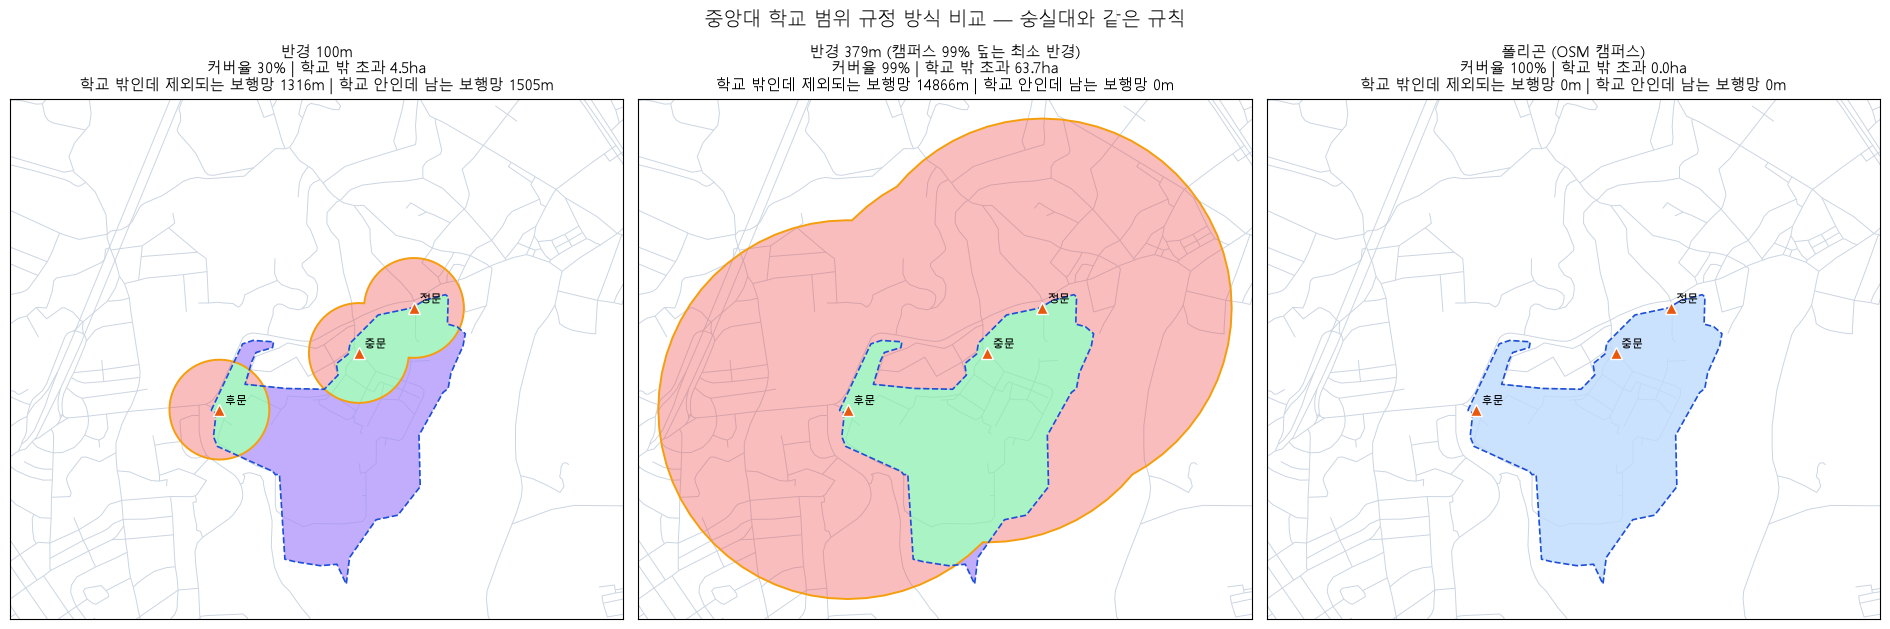

In [4]:
cau_walk_edges = cn.load_walk_edges()
cau_r_cover = viz.cover_radius(list(cau_gates.values()), cau_campus)
cau_regions = {'반경 100m': viz.union_of_circles(list(cau_gates.values()), 100),
               f'반경 {cau_r_cover:.0f}m (캠퍼스 99% 덮는 최소 반경)': viz.union_of_circles(list(cau_gates.values()), cau_r_cover),
               '폴리곤 (OSM 캠퍼스)': cau_campus}
cau_compare = pd.DataFrame({k: viz.evaluate(v, cau_campus, cau_walk_edges) for k, v in cau_regions.items()}).T.round(1)
display(cau_compare)

bx0, by0, bx1, by1 = unary_union(list(cau_regions.values())).bounds
extent = (bx0 - 40, by0 - 40, bx1 + 40, by1 + 40)
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (name, region) in zip(axes, cau_regions.items()):
    r = cau_compare.loc[name]
    title = (f"{name}\n커버율 {r['캠퍼스 커버율(%)']:.0f}% | 학교 밖 초과 {r['학교 밖 초과 면적(ha)']:.1f}ha\n"
             f"학교 밖인데 제외되는 보행망 {r['학교 밖인데 제외되는 보행망(m)']:.0f}m | 학교 안인데 남는 보행망 {r['학교 안인데 통학로로 남는 보행망(m)']:.0f}m")
    viz.draw_map(ax, title, cau_walk_edges, cau_campus, extent, None if region is cau_campus else region,
                 gates=cau_gates, gate_color='#ea580c')
fig.suptitle('중앙대 학교 범위 규정 방식 비교 — 숭실대와 같은 규칙', fontsize=14)
plt.tight_layout(rect=(0, 0, 1, .94)); plt.show()

### 중앙대 1단계 정리

- 비교 기준을 통일해 **카카오 ‘중앙대학교 서울캠퍼스’ 대표점 + 반경 800m**를 사용한다.
- 학교 범위는 OSM 캠퍼스 폴리곤, 출입문은 공식 명칭이 확인된 카카오 정문·중문·후문 좌표다.
- 기존 중앙대 정문 기준 분석과 중심점이 다르므로, 기존 1km 결과와 이번 비교용 800m 결과를 혼용하지 않는다.

---
## 중앙대 2. 구간·거리 규정

숭실대와 같은 규칙으로 OSM 보행망을 만든다. 800m 원보다 150m 넓게 받은 뒤 캠퍼스 내부 비율이 50% 이상인 엣지를 제거하고, 각 문을 가장 가까운 외부 노드에 가상 연결한다. 원 안·학교 밖 노드에서 보행거리상 가장 가까운 문까지의 최단경로와 엣지별 최단경로 중첩수를 계산한다.

OSM 보행망(원+150m): 노드 696, 엣지 996
학교 내부 엣지 제거: 41개, 2,580m -> 남은 노드 663, 엣지 955
연결 요소 수: 1
출발 노드: 333개, 문에 도달 못 하는 노드: 0개


,문,연결_노드,연결선_m,경고
0,정문,2890319153,14.7,False
1,중문,4613243825,14.8,False
2,후문,436883219,30.2,True


,노드수,평균_보행거리_m,최대_보행거리_m,엣지수(원 안),엣지길이_km
가까운_문,,,,,
후문,172,521.0,1334.0,255,16.50
정문,156,594.0,1586.0,226,15.71
중문,5,113.0,268.0,7,0.60


직선 최근접 문과 보행 최근접 문이 다른 노드: 17개 / 333개 (5.1%)
1·2순위 문 거리 차이가 50m 미만: 7개 (2.1%)


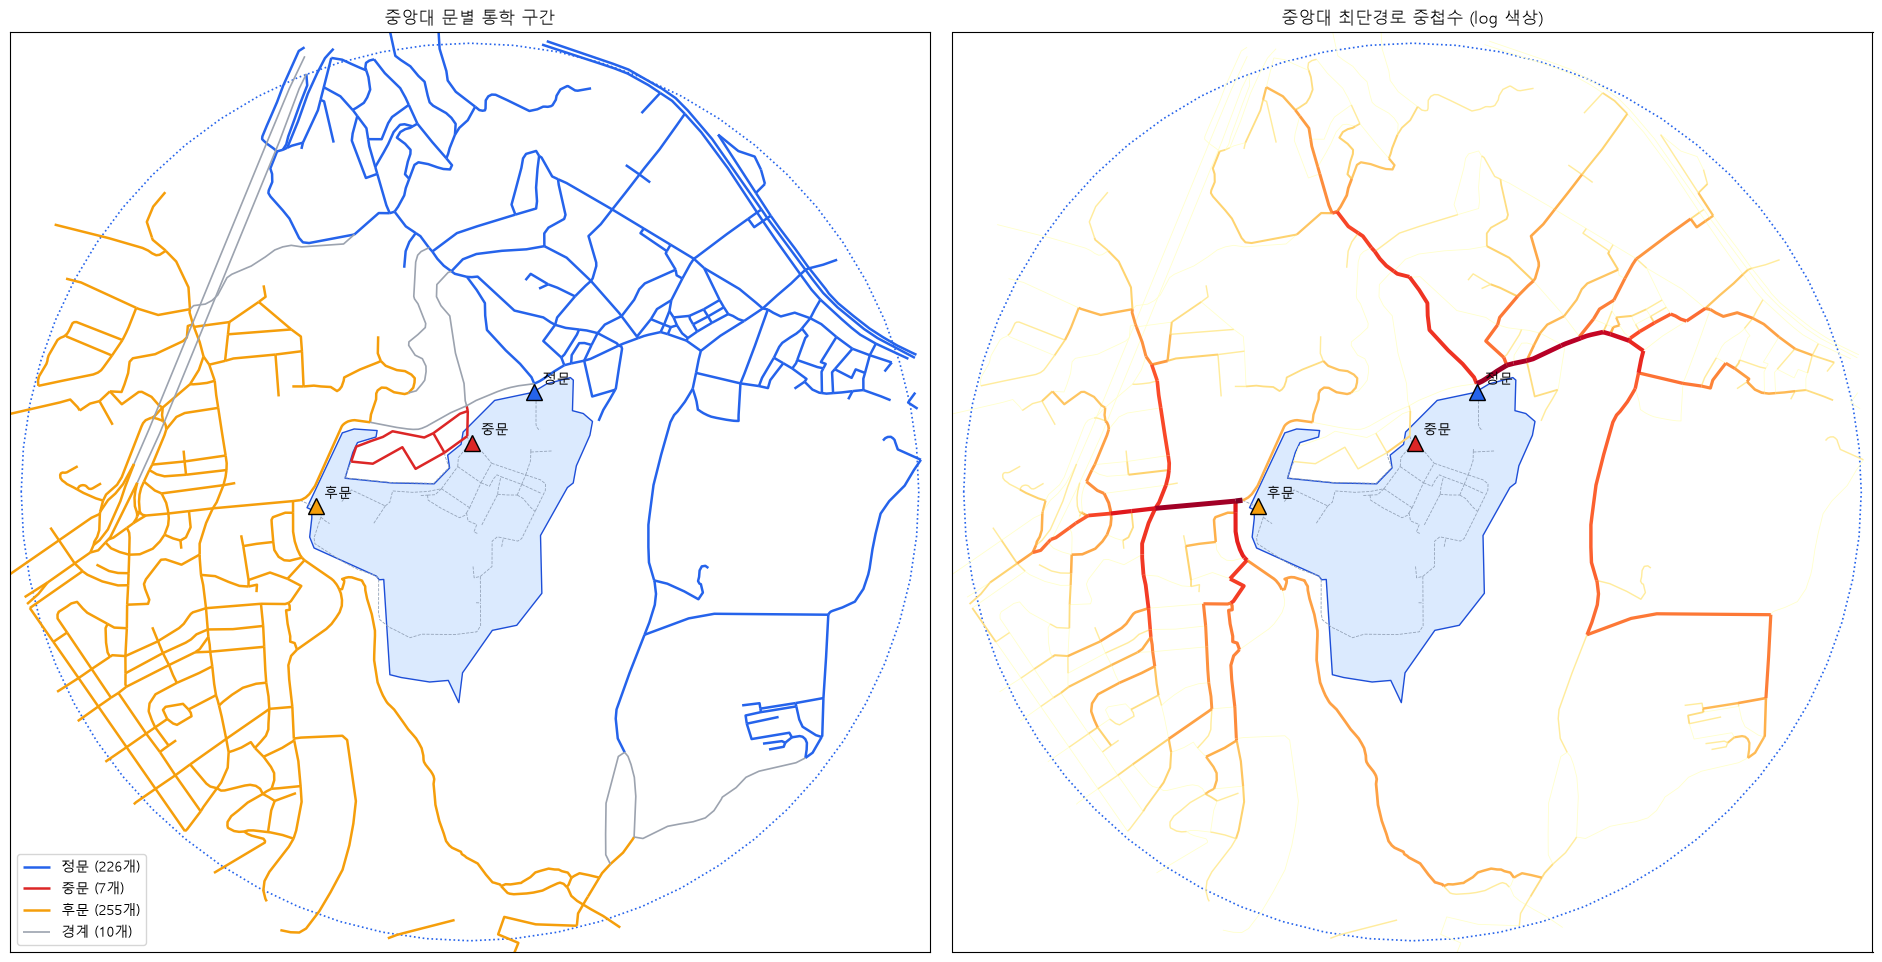

저장: chungang_network.gpkg (layers: edges, nodes | EPSG:4326)


In [5]:
cau_res = cn.run()
cau_nodes, cau_edges, cau_removed = cau_res['nodes'], cau_res['edges'], cau_res['removed']
cau_origins = cau_nodes[cau_nodes['출발노드']]
cau_ein = cau_edges[cau_edges['원_안'] & (cau_edges['highway'] != 'gate_connector')]
print(f"OSM 보행망(원+150m): 노드 {len(cau_res['G_full']):,}, 엣지 {cau_res['G_full'].number_of_edges():,}")
print(f"학교 내부 엣지 제거: {len(cau_removed)}개, {cau_removed.geometry.length.sum():,.0f}m -> 남은 노드 {len(cau_res['G_cut']):,}, 엣지 {cau_res['G_cut'].number_of_edges():,}")
print(f"연결 요소 수: {nx.number_connected_components(cau_res['G_cut'])}")
print(f"출발 노드: {len(cau_origins)}개, 문에 도달 못 하는 노드: {cau_origins['가까운_문'].isna().sum()}개")
display(cau_res['gate_table'])

cau_by_gate = cau_origins.groupby('가까운_문').agg(노드수=('node', 'size'), 평균_보행거리_m=('문까지_보행_m', 'mean'), 최대_보행거리_m=('문까지_보행_m', 'max')).round(0)
cau_by_gate['엣지수(원 안)'] = cau_ein.groupby('소속_문').size()
cau_by_gate['엣지길이_km'] = (cau_ein.assign(l=cau_ein.geometry.length).groupby('소속_문')['l'].sum() / 1000).round(2)
display(cau_by_gate.sort_values('노드수', ascending=False))
mis = cau_origins['가까운_문'] != cau_origins['직선_최근접_문']
close = cau_origins['1-2순위_차이_m'] < 50
print(f'직선 최근접 문과 보행 최근접 문이 다른 노드: {mis.sum()}개 / {len(cau_origins)}개 ({mis.mean()*100:.1f}%)')
print(f'1·2순위 문 거리 차이가 50m 미만: {close.sum()}개 ({close.mean()*100:.1f}%)')

cau_colors = {'정문': '#2563eb', '중문': '#dc2626', '후문': '#f59e0b', '경계': '#9ca3af'}
minx, miny, maxx, maxy = cau_res['circle'].bounds
fig, axes = plt.subplots(1, 2, figsize=(19, 9.5))
for ax in axes:
    gpd.GeoSeries([cau_res['campus']]).plot(ax=ax, color='#dbeafe', edgecolor='#1d4ed8', linewidth=1)
    cau_removed.plot(ax=ax, color='#94a3b8', linewidth=.6, linestyle='--')
    gpd.GeoSeries([cau_res['circle']]).boundary.plot(ax=ax, color='#2563eb', linestyle=':', linewidth=1.2)
    for name, p in cau_res['gates'].items():
        ax.plot(p.x, p.y, '^', ms=11, color=cau_colors[name], markeredgecolor='black', zorder=6); ax.annotate(name, (p.x, p.y), xytext=(6,6), textcoords='offset points')
    ax.set(xlim=(minx-20,maxx+20), ylim=(miny-20,maxy+20)); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
for name in ['정문','중문','후문','경계']:
    sub = cau_ein[cau_ein['소속_문'] == name]
    if len(sub): sub.plot(ax=axes[0], color=cau_colors[name], linewidth=1.8 if name != '경계' else 1.2, label=f'{name} ({len(sub)}개)')
axes[0].legend(loc='lower left'); axes[0].set_title('중앙대 문별 통학 구간')
use = cau_ein.sort_values('최단경로_중첩수'); norm = plt.Normalize(0, np.log1p(use['최단경로_중첩수'].max()))
use.plot(ax=axes[1], color=plt.cm.YlOrRd(norm(np.log1p(use['최단경로_중첩수']))), linewidth=.6 + 3.2*norm(np.log1p(use['최단경로_중첩수'])))
axes[1].set_title('중앙대 최단경로 중첩수 (log 색상)'); plt.tight_layout(); plt.show()

cau_out = cn.save(cau_res)
print('저장:', cau_out.name, '(layers: edges, nodes | EPSG:4326)')

### 중앙대 2단계 정리

- 산출물: `data/chungang_network.gpkg` (`edges`, `nodes`, EPSG:4326).
- 통학 구간의 뜻과 최단경로 중첩수의 한계는 숭실대 2단계와 같다. 실제 통행량이 아니라 원 안 노드들이 가장 가까운 문으로 향한다고 가정한 경로 중첩이다.
- 후문 가상 연결선이 25m를 넘으면 경고로 남긴다. 이는 OSM 보행망 또는 캠퍼스 경계의 누락 가능성을 뜻하므로 현장·지도 확인 대상이다.
- 병원·부속학교 출입구는 중앙대 캠퍼스 문에서 제외했다.

---
# C. 두 학교 결과 비교

| 항목 | 숭실대 | 중앙대 |
|---|---:|---:|
| 카카오 출입문 | 5개 | 3개 |
| OSM 캠퍼스 면적 | 12.5ha | 14.5ha |
| 원+150m 보행망 노드 / 엣지 | 797 / 1,122 | 696 / 996 |
| 학교 내부 제거 엣지 / 길이 | 71개 / 3,109m | 41개 / 2,580m |
| 제거 후 연결 요소 | 1개 | 1개 |
| 원 안·학교 밖 출발 노드 | 400개 | 333개 |
| 문에 도달 못 하는 노드 | 0개 | 0개 |
| 직선 최근접 문 ≠ 보행 최근접 문 | 60개 (15.0%) | 17개 (5.1%) |
| 1·2순위 문 거리 차이 < 50m | 51개 (12.8%) | 7개 (2.1%) |
| 25m 초과 가상 연결선 | 없음 | 후문 30.2m |
| 저장 파일 | `data/soongsil_network.gpkg` | `data/chungang_network.gpkg` |

두 학교 모두 학교 내부 엣지를 제거한 뒤 외부 보행망이 하나의 연결 요소로 유지되고, 모든 출발 노드가 문에 도달한다. 중앙대 후문의 30.2m 가상 연결선은 OSM 보행망 또는 경계 누락 가능성이 있으므로 별도 확인 대상으로 남긴다.

중앙대의 중문은 보행거리 기준 담당 노드가 5개뿐이다. 이는 문 자체의 중요도가 낮다는 뜻이 아니라, 현재 OSM 외부 보행망·캠퍼스 경계·최단거리 가정 아래에서 중문이 최근접 문인 영역이 작다는 뜻이다.

---
# D. 예비 실험 — 대중교통 출발지 TMAP·OSM 정합 검증

통학로를 다음과 같이 최종 규정한다.

> **반경 800m 안의 실제 통학 출발지에서, 같은 학교의 검증된 모든 출입문까지 TMAP 보행경로를 조회하고, 도보거리가 가장 짧은 문으로 향하는 경로를 해당 출발지의 통학로로 채택한다.**

TMAP은 실제 추천 도보 경로를 선택·검증하는 역할, OSM은 경로를 엣지 단위로 나누어 경사·횡단보도·음향신호기·사고위험을 붙이는 역할로 분리한다.

## D-1. 출발지 지정

1차 출발지는 반경 800m 안의 **지하철 출구와 버스정류장**으로 정한다.

- 지하철 출구: OSM `railway=subway_entrance`; 가까운 Kakao 역명으로 이름 보정
- 버스정류장: OSM `highway=bus_stop`
- 정류장 도로 양쪽은 서로 다른 승하차 위치이므로 별도 출발지로 유지
- 향후 주거 밀집지·주요 횡단보도 등을 추가할 수 있도록 출발지 표를 독립 CSV로 관리

이 목록은 TMAP 데이터가 아니므로 지속 저장할 수 있다.

In [1]:
import os
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from dotenv import load_dotenv
import tmap_commute_pipeline as tcp

origin_path = Path('data/commute_origin_candidates.csv')
origins = pd.read_csv(origin_path) if origin_path.exists() else tcp.collect_origin_candidates()
gates_tmap = tcp.load_gates()
display(origins.groupby(['학교', '출발지유형']).size().rename('출발지수').to_frame())
display(origins.sort_values(['학교', '출발지유형', '중심점거리_m']).head(15))
print(f'전체 출발지 {len(origins)}개, 문 {len(gates_tmap)}개')

출발지수
학교  출발지유형      
숭실대 버스정류장    44
    지하철출구     4
중앙대 버스정류장    69
    지하철출구     4

,학교,출발지유형,출발지명,lat,lon,중심점거리_m,source,source_id,주소
0,숭실대,버스정류장,숭실대중문앞,37.495284,126.957239,81.2,OSM,node/357855342,NaN
1,숭실대,버스정류장,숭실대중문앞,37.495225,126.956933,104.8,OSM,node/357855810,NaN
2,숭실대,버스정류장,숭실대레지던스홀앞,37.494936,126.959835,205.4,OSM,node/357855661,NaN
3,숭실대,버스정류장,숭실대정보과학관앞,37.494769,126.960280,248.8,OSM,node/11638012220,NaN
4,숭실대,버스정류장,삼성래미안아파트,37.497832,126.959271,254.5,OSM,node/11638012223,NaN
5,숭실대,버스정류장,테니스장앞,37.498077,126.959373,282.6,OSM,node/11638012224,NaN
6,숭실대,버스정류장,숭실대후문,37.494908,126.960919,293.6,OSM,node/11638012221,NaN
7,숭실대,버스정류장,숭실대후문,37.494895,126.961012,301.8,OSM,node/11638012222,NaN
8,숭실대,버스정류장,숭실대입구역2번출구,37.495962,126.953767,358.4,OSM,node/11552941601,NaN
9,숭실대,버스정류장,숭실대입구역,37.496371,126.953721,366.8,OSM,node/11552941603,NaN


전체 출발지 121개, 문 8개


C:\Users\kjyil\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Glyph 49709 (\N{HANGUL SYLLABLE SUNG}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
C:\Users\kjyil\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
C:\Users\kjyil\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
C:\Users\kjyil\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
C:\Users\kjyil\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Glyph 51613 (\N{HANGU

C:\Users\kjyil\AppData\Local\Temp\ipykernel_30164\1440037435.py:16: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kjyil\AppData\Local\Temp\ipykernel_30164\1440037435.py:16: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kjyil\AppData\Local\Temp\ipykernel_30164\1440037435.py:16: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kjyil\AppData\Local\Temp\ipykernel_30164\1440037435.py:16: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kjyil\AppData\Local\Temp\ipykernel_30164\1440037435.py:16: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kjyil\AppData\Local\Temp\ipykernel_30164\1440037435.py:16

C:\Users\kjyil\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49709 (\N{HANGUL SYLLABLE SUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kjyil\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kjyil\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kjyil\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kjyil\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 5

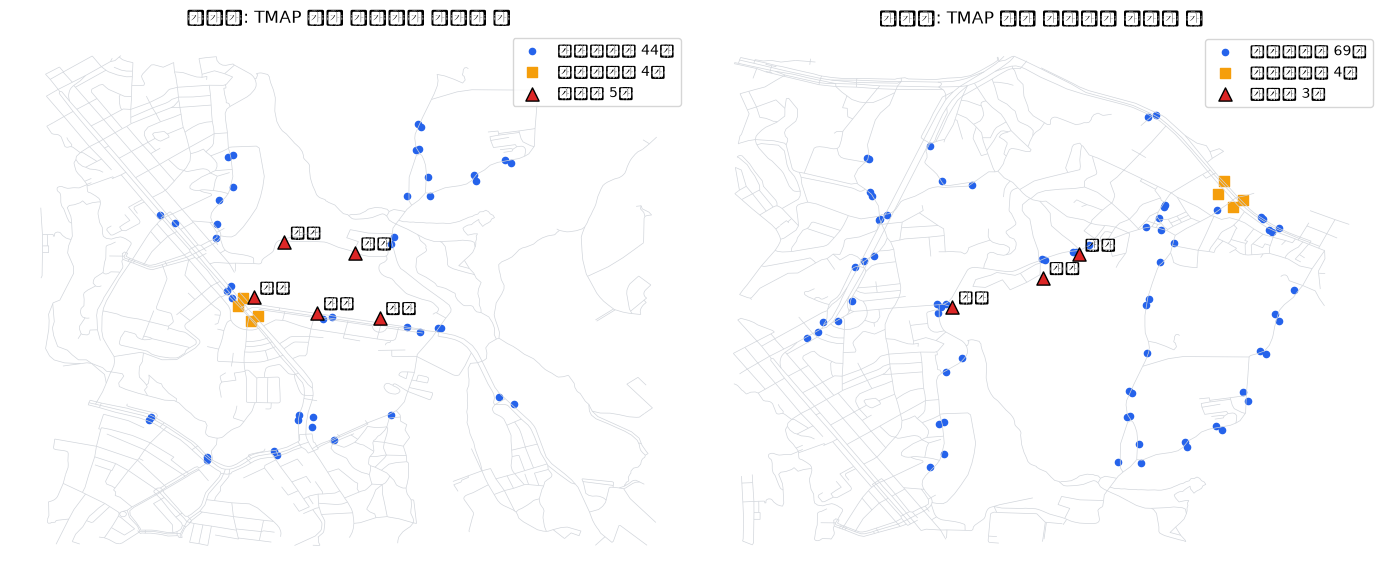

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = {'버스정류장': '#2563eb', '지하철출구': '#f59e0b'}
for ax, school in zip(axes, ['숭실대', '중앙대']):
    spec = tcp.SCHOOLS[school]
    edge = gpd.read_file(spec['network_file'], layer='edges')
    edge.plot(ax=ax, color='#d1d5db', linewidth=.5)
    sub = gpd.GeoDataFrame(origins[origins['학교'].eq(school)].copy(),
                           geometry=gpd.points_from_xy(origins.loc[origins['학교'].eq(school), 'lon'], origins.loc[origins['학교'].eq(school), 'lat']), crs='EPSG:4326')
    for kind, group in sub.groupby('출발지유형'):
        group.plot(ax=ax, color=colors[kind], markersize=20 if kind == '버스정류장' else 55,
                   marker='o' if kind == '버스정류장' else 's', label=f'{kind} {len(group)}개')
    gate = gates_tmap[gates_tmap['학교'].eq(school)]
    ax.scatter(gate['lon'], gate['lat'], marker='^', s=90, color='#dc2626', edgecolor='black', label=f'출입문 {len(gate)}개', zorder=5)
    for r in gate.itertuples(): ax.annotate(r.문, (r.lon, r.lat), xytext=(4,4), textcoords='offset points')
    ax.set_title(f'{school}: TMAP 검증 출발지와 목적지 문'); ax.set_aspect('equal'); ax.legend(); ax.set_axis_off()
plt.tight_layout(); plt.show()

## D-2. 경로 선택·검증·OSM 연결

1. 출발지 하나에서 같은 학교의 모든 문으로 TMAP 보행경로 요청
2. 성공한 경로 중 TMAP 도보거리가 가장 짧은 문 선택
3. 경로를 10m 간격으로 표본화
4. 각 표본점을 20m 이내의 가장 가까운 OSM 엣지에 연결
5. 경로별 OSM 매칭률과 매칭 엣지 수 확인
6. 매칭 엣지에 경사·횡단보도·음향신호기·사고위험 결합

정문만 분석하고 싶을 때는 목적지를 정문으로 고정할 수 있다. 기본 비교에서는 특정 문을 미리 강제하지 않고 모든 문 중 실제 보행거리가 가장 짧은 문을 선택한다.

In [3]:
load_dotenv('.env')
has_tmap_key = bool(os.getenv('TMAP_APP_KEY'))
planned_calls = sum(len(origins[origins['학교'].eq(s)]) * len(gates_tmap[gates_tmap['학교'].eq(s)]) for s in tcp.SCHOOLS)
print('TMAP_APP_KEY:', '설정됨' if has_tmap_key else '미설정')
print(f'예상 API 호출: {planned_calls:,}회')
print('실행 원칙: TMAP 원본 경로는 메모리에서만 처리하고 24시간 이상 저장하지 않음')

TMAP_APP_KEY: 설정됨
예상 API 호출: 459회
실행 원칙: TMAP 원본 경로는 메모리에서만 처리하고 24시간 이상 저장하지 않음


In [4]:
# 전체 API 호출은 명시적으로 True로 바꿀 때만 실행한다.
# 오늘 검증은 완료되었으므로 불필요한 재호출을 막기 위해 기본값은 False다.
RUN_TMAP = False
if not has_tmap_key:
    print('대기: .env.tmap에 TMAP_APP_KEY가 필요합니다.')
elif not RUN_TMAP:
    print('TMAP 검증 완료. 다시 조회하려면 RUN_TMAP=True로 바꾸세요.')
else:
    routes_24h = tcp.run_all_routes(origins)
    chosen_24h = tcp.choose_nearest_gate(routes_24h)
    matched_edges, match_summary = tcp.match_routes_to_osm(chosen_24h)
    display(chosen_24h[['학교','origin_id','출발지명','문','distance_m','time_s','expires_at']].head())
    display(match_summary.groupby('학교').agg(경로수=('origin_id','size'), 평균_OSM매칭률=('매칭률_pct','mean')).round(1))

TMAP 검증 완료. 다시 조회하려면 RUN_TMAP=True로 바꾸세요.


## D-3. TMAP 실제 검증 결과 (2026-09-23)

- 전체 요청: **459건** (121개 출발지 × 같은 학교의 모든 문)
- 성공: **459건**, 실패: **0건**
- 출발지별 최단 보행거리 문 선택: **121건 전부 완료**
- 원본 TMAP 경로 geometry는 집계 후 폐기

| 학교 | 선택 문별 출발지 수 | 평균 최단거리 | 중앙 최단거리 | 평균시간 |
|---|---|---:|---:|---:|
| 숭실대 | 정문 12 · 중문 13 · 후문 13 · 남문 7 · 북문 3 | 461.4m | 508m | 372.8초 |
| 중앙대 | 정문 46 · 중문 2 · 후문 25 | 682.6m | 661m | 528.8초 |

### 문별 선택 경로 평균

| 학교 | 문 | 출발지 수 | 평균거리 | 평균시간 |
|---|---|---:|---:|---:|
| 숭실대 | 정문 | 12 | 265.3m | 230.6초 |
| 숭실대 | 중문 | 13 | 659.6m | 527.3초 |
| 숭실대 | 후문 | 13 | 490.3m | 392.6초 |
| 숭실대 | 남문 | 7 | 344.9m | 270.3초 |
| 숭실대 | 북문 | 3 | 533.7m | 426.0초 |
| 중앙대 | 정문 | 46 | 801.0m | 612.8초 |
| 중앙대 | 중문 | 2 | 85.5m | 62.5초 |
| 중앙대 | 후문 | 25 | 512.5m | 411.3초 |

### TMAP 경로와 OSM 엣지의 정합

TMAP 경로를 10m 간격으로 표본화하고 20m 이내의 최근접 OSM 엣지에 연결했다.

| 학교 | 경로 수 | 평균 매칭률 | 중앙 매칭률 | 최소 매칭률 |
|---|---:|---:|---:|---:|
| 숭실대 | 48 | 99.9% | 100.0% | 96.3% |
| 중앙대 | 73 | 100.0% | 100.0% | 97.6% |

따라서 TMAP이 선택한 실제 추천 보행경로를 기존 OSM 엣지 분석 단위에 연결하는 구조가 두 학교 모두에서 작동한다. 다음 단계는 이 매칭 엣지에 경사·횡단보도·음향신호기·사고위험 값을 결합하는 것이다.

## D-4. 현재 상태와 다음 실행

| 단계 | 상태 |
|---|---|
| 출발지 규칙·후보 CSV | 완료 |
| 학교별 출입문 좌표 | 완료 |
| TMAP 모든 문 경로 요청 코드 | 완료 |
| 최단 보행거리 문 선택 코드 | 완료 |
| TMAP 경로 → OSM 엣지 매칭 코드 | 완료 |
| 실제 TMAP 호출 | 완료: 459/459 성공 |
| 경사·횡단보도·음향신호기·사고위험 결합 | 다음 단계 |

TMAP API 결과는 약관상 저장 후 24시간 이상 사용할 수 없으므로, 원본 경로 GeoJSON을 장기 산출물로 저장하지 않는다. 재현 가능한 출발지·문 정의와 OSM 위험도 데이터는 별도로 유지하고, TMAP 경로는 실행 시점의 검증 레이어로 사용한다.

# E. 예비 실험 결과 시각화

아래 그림은 **TMAP 보행경로 검증 결과**와 **OSM 통학로 회랑**을 한 화면에서 비교한다.

- 지도 선의 **색**: 연결되는 학교 출입문
- 지도 선의 **굵기**: OSM 최단경로 중첩수(많이 겹칠수록 굵음)
- 작은 원: 버스정류장, 큰 사각형: 지하철 출구, 삼각형: 학교 출입문
- 하단 차트: TMAP이 선택한 출입문 수와 출발지별 평균 거리·시간


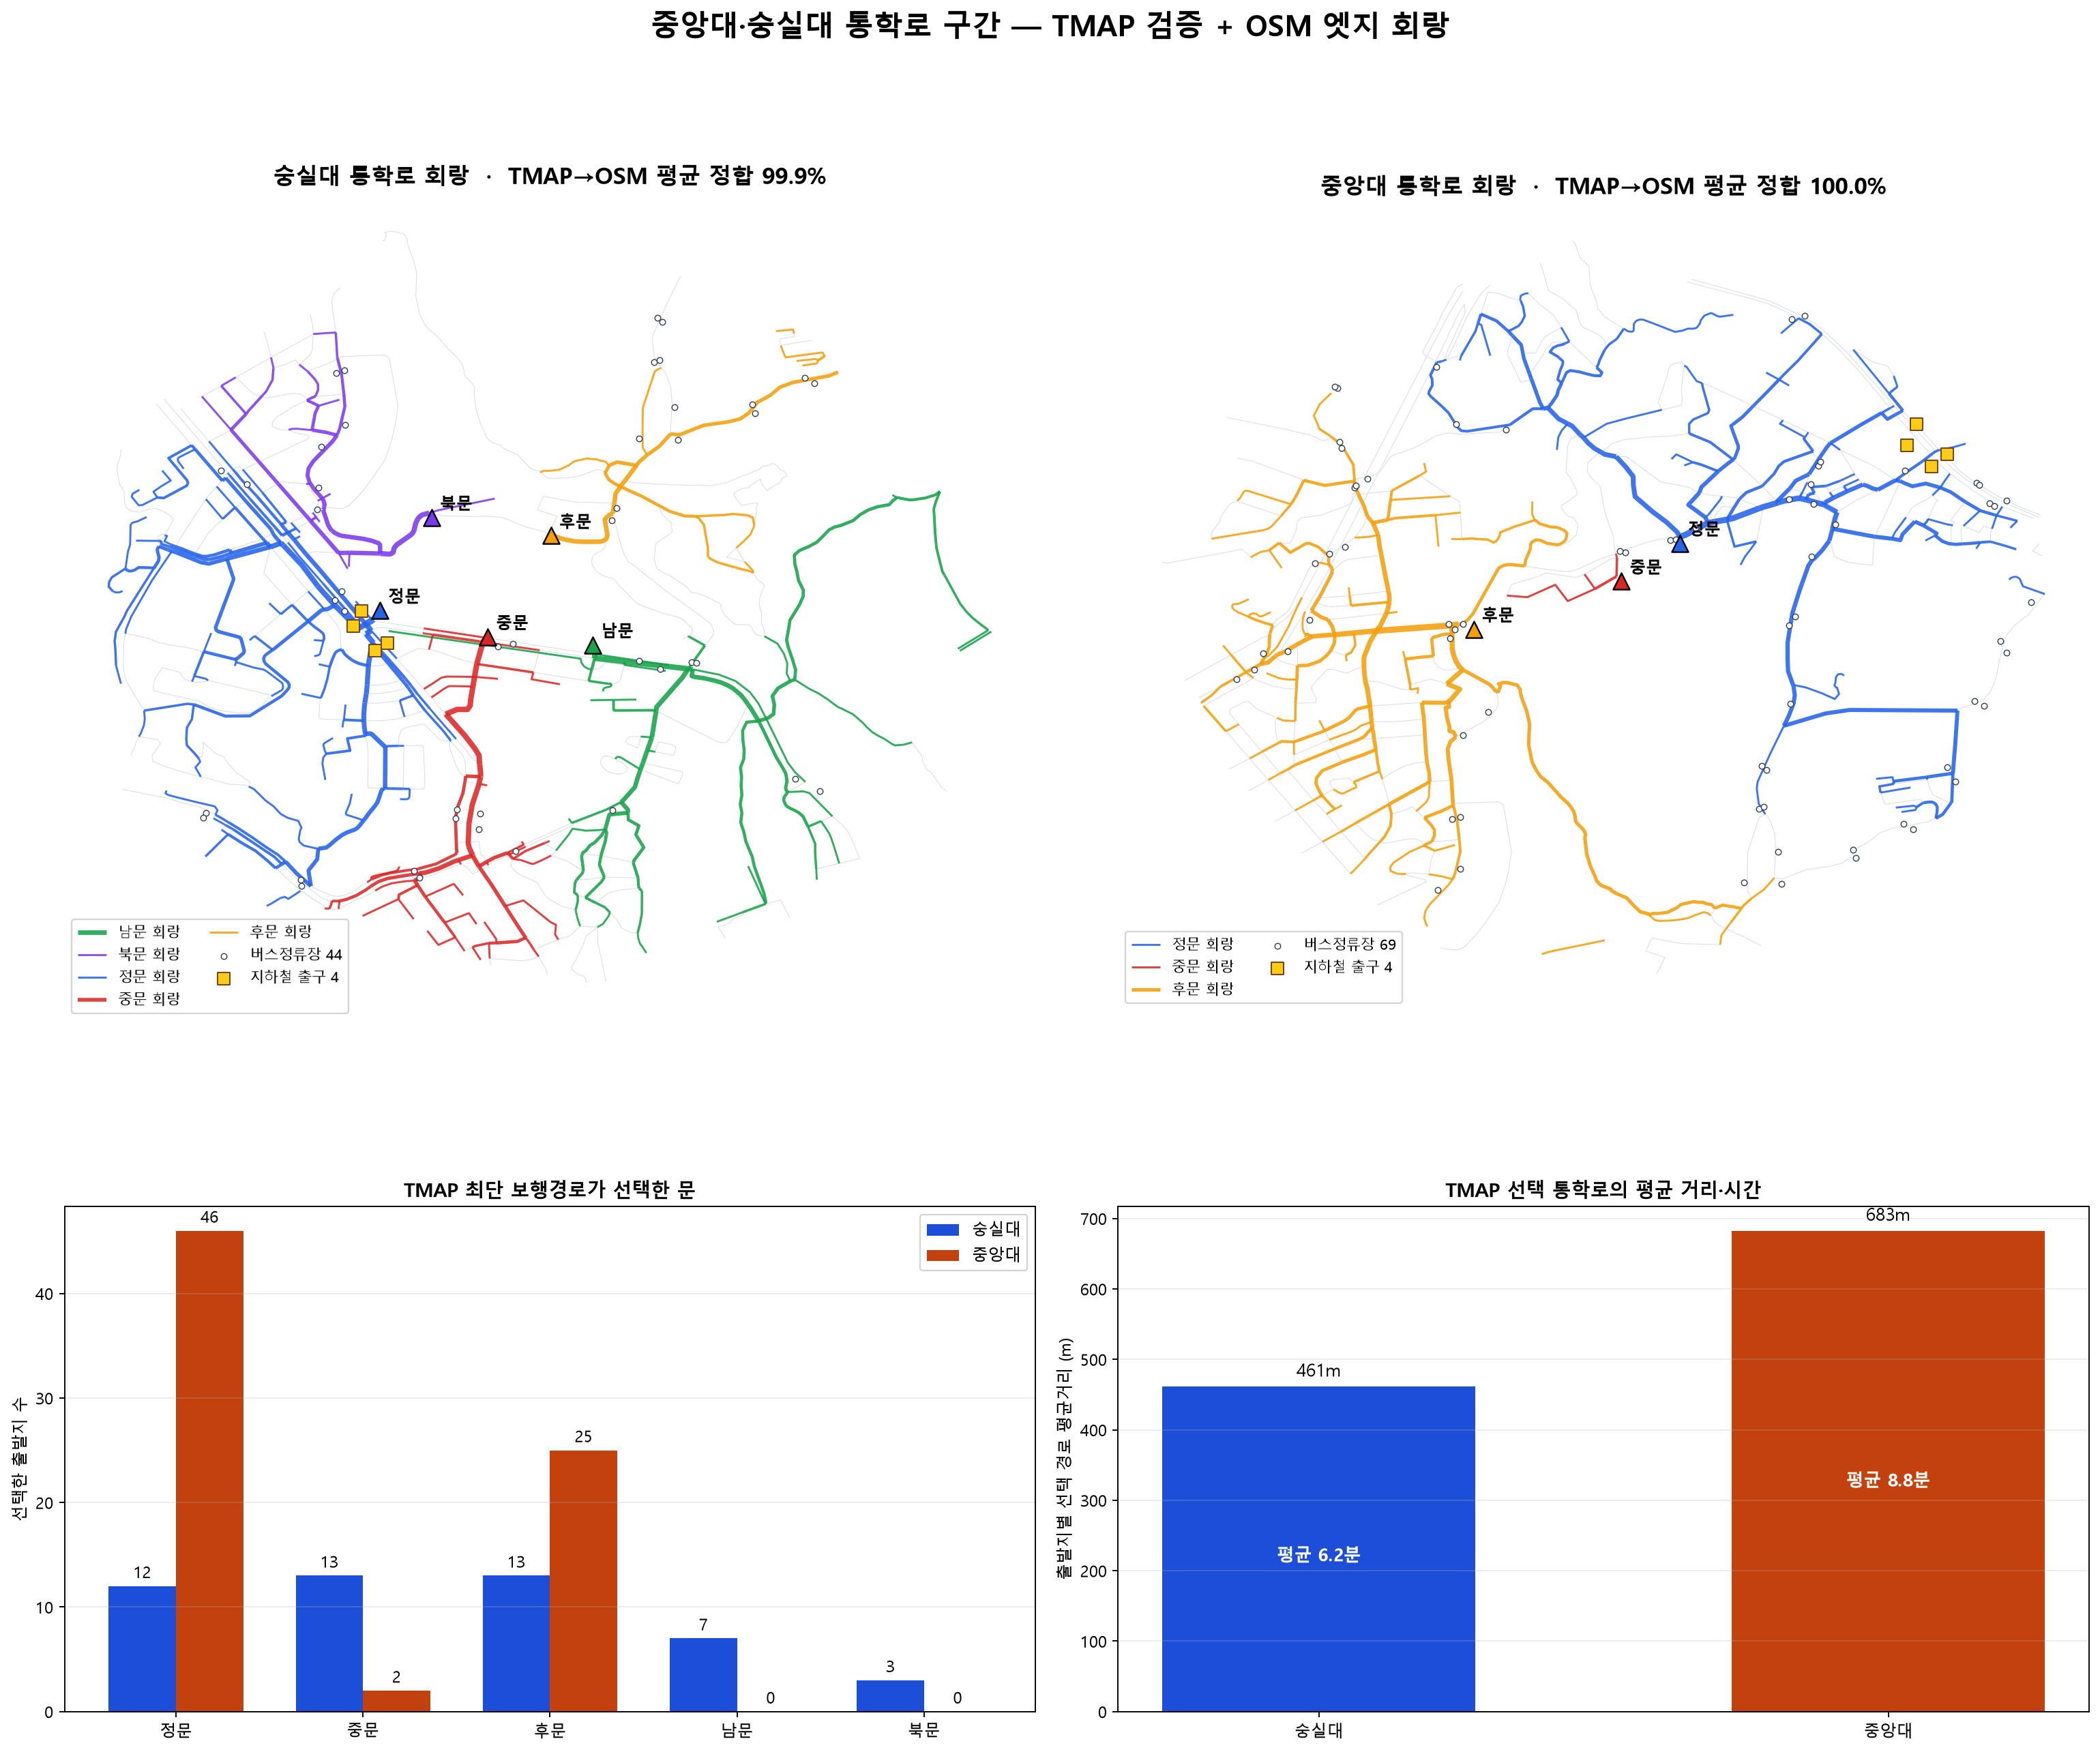

In [1]:
from IPython.display import Image, display

display(Image(filename='figures/commute_routes/tmap_validated_commute_corridors.png'))

## E-1. 읽는 방법과 해석

**TMAP 검증 요약**

| 학교 | 출발지 수 | TMAP 선택 출입문 | 평균 거리 | 평균 시간 | TMAP→OSM 평균 정합률 |
|---|---:|---|---:|---:|---:|
| 숭실대 | 48 | 정문 12 · 중문 13 · 후문 13 · 남문 7 · 북문 3 | 461.4 m | 6.2분 | 99.9% |
| 중앙대 | 73 | 정문 46 · 중문 2 · 후문 25 | 682.6 m | 8.8분 | 100.0% |

출발지마다 가장 가까운 문이 달라지므로 정문 하나만 목적지로 고정하는 것보다, 모든 확인된 출입문에 대해 TMAP 보행거리를 비교하는 구조가 실제 통학 흐름을 더 잘 반영한다. 특히 중앙대는 정문 선택이 우세하지만 후문으로 연결되는 출발지도 25곳으로 적지 않다.

> **표현 범위:** TMAP 원본 경로 좌표는 보관 제한을 고려해 집계 후 폐기했다. 따라서 지도에 그려진 선은 개별 TMAP 원본 선이 아니라, TMAP 경로와 평균 99.9~100% 정합한 **OSM 기반 통학로 회랑**이다. 정확한 개별 TMAP 경로를 재현한 그림으로 해석하면 안 된다.

인터랙티브 지도에서는 학교별 회랑·출발지·출입문 레이어를 켜고 끌 수 있으며, 선을 가리키면 담당 문, 중첩수, 도로 유형과 도로명을 확인할 수 있다.


In [2]:
from IPython.display import IFrame, display

display(IFrame(src='figures/commute_routes/tmap_validated_commute_corridors.html', width='100%', height=720))

# F. 최종 구조 수정 — OSM 후보 엣지를 TMAP 실제 경로로 필터링

앞의 D·E는 **대중교통 출발지로 TMAP→OSM 정합 가능성을 확인한 예비 실험**이다. 최종 분석의 목적은 TMAP으로 출발지를 정의하는 것이 아니라, **OSM이 만든 후보 도로 중 실제 TMAP 도보경로에서 관측되는 엣지만 남기는 것**이다.

최종 기준은 다음과 같다.

1. 학교 범위: OSM 캠퍼스 폴리곤
2. 출입문 좌표: OSM 보행로와 캠퍼스 경계의 교차점
3. 출발지: 800m 학교 밖 영역의 층화 임의 좌표
4. 임의 좌표를 `ox.distance.nearest_nodes`로 OSM 보행 노드에 스냅
5. 스냅된 출발 노드에서 OSM 보행거리상 최근접 문을 결정
6. 동일 출발 노드·OSM 문으로 TMAP 실제 보행경로 요청
7. TMAP 경로를 OSM 엣지에 매칭하고 `validated` / `unobserved`로 분류
8. 본 분석은 `validated` 엣지와 15m 이하 간격을 OSM으로 이은 `bridged` 엣지를 사용하고, `unobserved`는 검토용으로 보존

> TMAP에 한 번도 선택되지 않은 엣지는 ‘보행 불가’로 단정하지 않고 ‘현재 표본에서 미관측’으로 기록한다.


In [1]:
import pandas as pd
from IPython.display import display

osm_gates = pd.concat([
    pd.read_csv('data/soongsil_osm_gates.csv').assign(학교='숭실대'),
    pd.read_csv('data/chungang_osm_gates.csv').assign(학교='중앙대'),
], ignore_index=True)
option_a = pd.read_csv('data/option_a_origins_with_osm_gate.csv')

display(osm_gates[['학교', '문', 'lat', 'lon', 'osm_way_id', 'highway', 'seed_distance_m']])
display(option_a.groupby(['학교', 'OSM_최근접_문']).agg(
    표본수=('node', 'size'), 평균스냅거리_m=('snap_distance_m', 'mean'),
    최대스냅거리_m=('snap_distance_m', 'max'), 평균문거리_m=('OSM_문까지_m', 'mean')
).round(1))
print(f'중복 제거 후 총 표본 노드: {len(option_a)}개')
print(f'기본 TMAP 호출: {len(option_a)}회 (2026-09-23 실행 완료, 아래 F-2)')

,학교,문,lat,lon,osm_way_id,highway,seed_distance_m
0,숭실대,정문,37.495745,126.954674,1382626815,pedestrian,29.3
1,숭실대,후문,37.497483,126.958017,1381930919,service,3.2
2,숭실대,남문,37.495105,126.958930,1381098993,service,17.9
3,숭실대,북문,37.497927,126.955538,367389875,service,5.1
4,숭실대,중문,37.495440,126.956704,1381930941,service,2.3
5,중앙대,정문,37.506797,126.958505,285364022,service,5.4
6,중앙대,중문,37.505975,126.956993,466546144,service,20.6
7,중앙대,후문,37.504957,126.953909,285364024,service,14.3


표본수  평균스냅거리_m  최대스냅거리_m  평균문거리_m
학교  OSM_최근접_문                                  
숭실대 남문          21      54.1      99.8    689.4
    북문          10      44.9      81.9    476.9
    정문          24      34.1      87.0    544.1
    중문          10      22.3      66.0    661.3
    후문          14      59.2     128.4    542.4
중앙대 정문          38      42.0     146.0    664.1
    중문           2      22.0      23.8    153.8
    후문          34      35.9      94.0    553.9

중복 제거 후 총 표본 노드: 153개
기본 TMAP 호출: 153회 (2026-09-23 실행 완료, 아래 F-2)


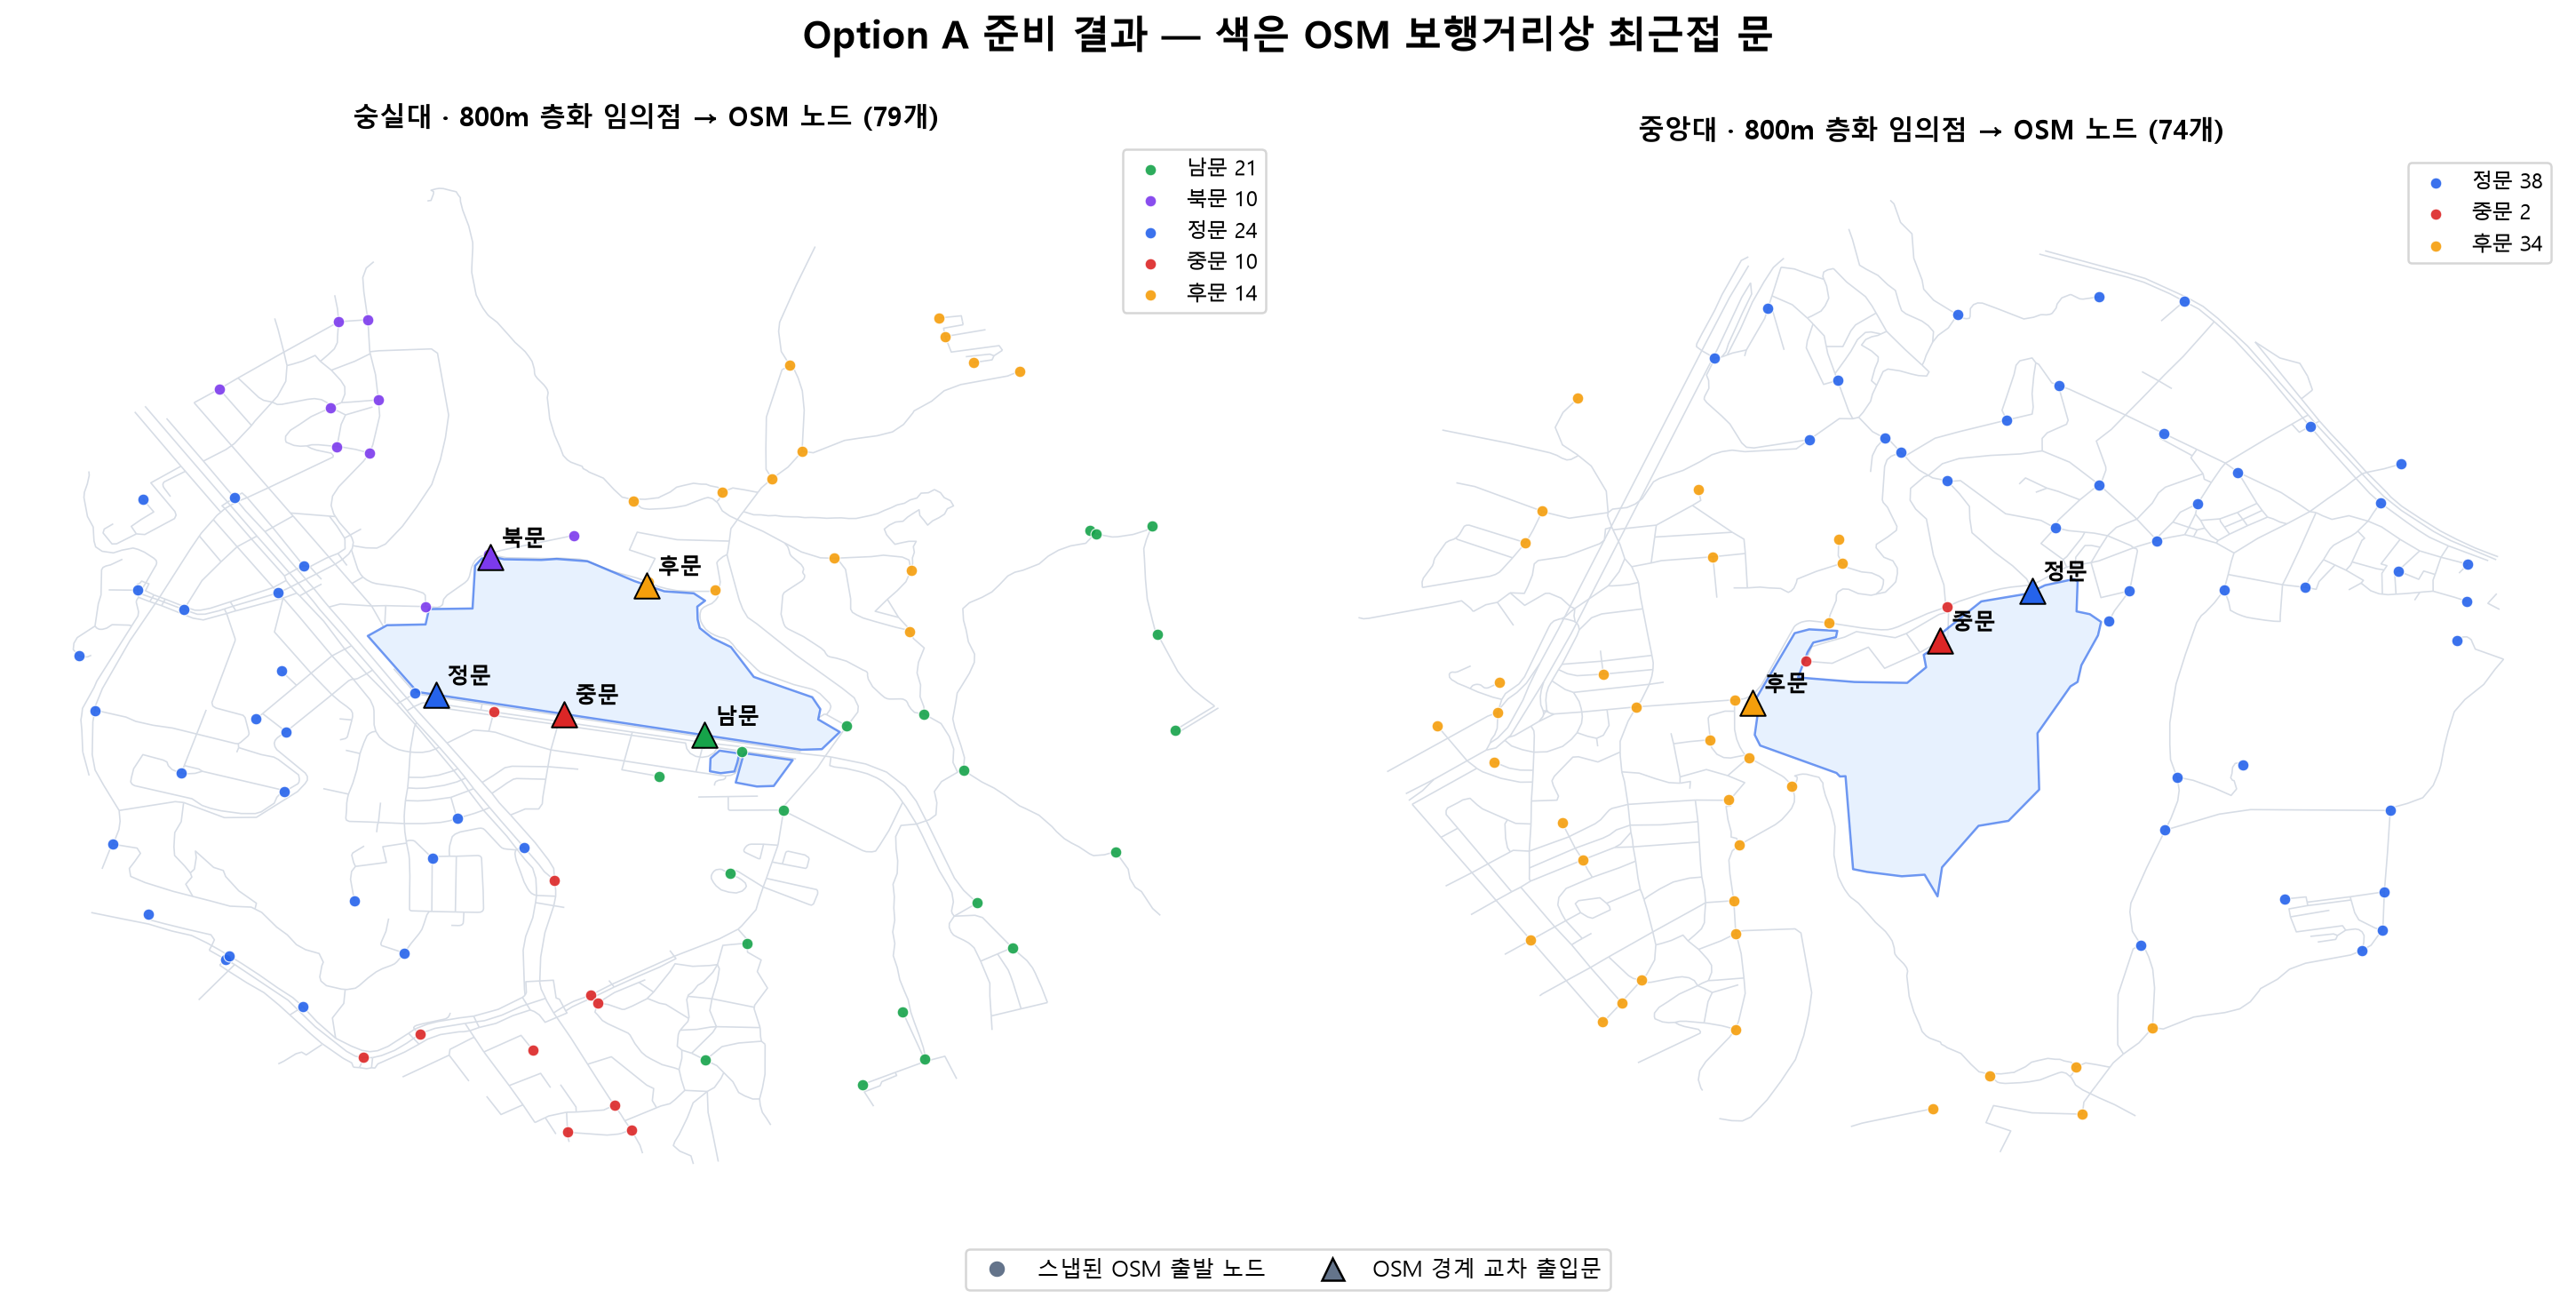

In [2]:
from IPython.display import Image, display
display(Image(filename='figures/option_a/option_a_random_origins_osm_gates.png'))

## F-1. 준비 결과와 실행 경계

- OSM 출입문: 숭실대 5개, 중앙대 3개
- 150m 격자별 임의점 생성 후 OSM 노드 중복 제거: 숭실대 79개, 중앙대 74개, 총 153개
- 문 진입 노드: 2단계 네트워크의 `gate_connector` 노드를 사용한다. 단순 최근접 노드로 붙이면 숭실대 정문이 1.6m 차이로 389m 막다른 footway 끝 노드에 붙어(실제 진입 노드와 보행망상 840m) 정문 배정이 0개가 되는 오류가 있었다(2026-09-23 수정). 수정 후 숭실대 24개 표본이 북문 10·중문 14에서 정문으로 옮겨졌고, 중앙대 배정은 변화 없음
- 기본 실행: 출발 노드당 OSM 최근접 문 1개를 TMAP으로 검증하므로 153회 호출
- TMAP 요청 한 건이 실패해도 전체 실행이 멈추지 않고 오류를 기록한 뒤 계속 진행
- 모든 문 비교 모드는 617회가 필요하지만 엣지 필터 목적에는 기본 모드를 우선 사용
- 실제 API 호출은 `run_option_a_tmap_filter.py --execute --confirm-calls 153`처럼 호출 수를 명시적으로 확인해야만 가능
- 원본 TMAP geometry는 저장하지 않고 OSM 엣지별 관측 경로 수와 집계만 저장

이 섹션의 셀은 저장된 로컬 자료만 읽으며 TMAP·Kakao·OSM API를 호출하지 않는다.


## F-2. TMAP 필터 실행 결과 (153회, 2026-09-23)

사용자 승인 후 `run_option_a_tmap_filter.py --execute --confirm-calls 153`으로 153회를 요청했고 153건 모두 성공했다. 원본 TMAP geometry는 저장하지 않았고 경로별 매칭 요약과 OSM 엣지별 관측 경로 수만 남겼다.

**간격 보정(bridged):** 10m 표본이 짧은 연결 엣지를 건너뛰거나 평행 엣지에 붙어 validated 엣지가 숭실대 14조각, 중앙대 13조각으로 끊겼다. 대부분 0.6–13m 간격이었으므로, 다른 조각까지 OSM 보행망 최단거리가 **15m 이하**인 경우만 그 경로 엣지를 `bridged`로 추가했다. 분석망 = `validated` + `bridged`. 15m를 넘는 간격(숭실대 18.9·67.5m, 중앙대 42.7·105.2m 등)은 TMAP이 OSM에 없는 길을 썼을 가능성이 있어 잇지 않고 한계로 남긴다.


In [3]:
import geopandas as gpd
import networkx as nx

route_summary = pd.read_csv('data/option_a_tmap_route_match_summary.csv')
display(route_summary.groupby('학교').agg(
    경로수=('origin_id', 'size'), TMAP거리_중앙값_m=('TMAP거리_m', 'median'),
    매칭률_평균=('매칭률_pct', 'mean'), 매칭률_최소=('매칭률_pct', 'min'),
    매칭률90미만=('매칭률_pct', lambda s: int((s < 90).sum())),
).round(1))

rows = []
for school, slug in [('숭실대', 'soongsil'), ('중앙대', 'chungang')]:
    e = gpd.read_file(f'data/{slug}_tmap_validated_network.gpkg', layer='all_edges')
    status = e['validation_status'].value_counts()
    def n_comp(frame):
        return nx.number_connected_components(nx.from_pandas_edgelist(frame, 'u', 'v'))
    rows.append({
        '학교': school, '전체엣지': len(e),
        'validated': status.get('validated', 0), 'bridged': status.get('bridged', 0),
        'unobserved': status.get('unobserved', 0),
        '분석망_km': round(e.loc[e['analysis_edge'], 'length'].sum() / 1000, 1),
        '전체_km': round(e['length'].sum() / 1000, 1),
        '경로1개만_지난_엣지': int(e['tmap_hit_routes'].eq(1).sum()),
        '조각수_보정전': n_comp(e[e['validation_status'].eq('validated')]),
        '조각수_보정후': n_comp(e[e['analysis_edge']]),
    })
display(pd.DataFrame(rows).set_index('학교'))
display(pd.read_csv('data/option_a_bridged_gaps.csv'))

,경로수,TMAP거리_중앙값_m,매칭률_평균,매칭률_최소,매칭률90미만
학교,,,,,
숭실대,79,642.0,98.7,84.0,1
중앙대,74,581.0,99.7,80.5,1


,전체엣지,validated,bridged,unobserved,분석망_km,전체_km,경로1개만_지난_엣지,조각수_보정전,조각수_보정후
학교,,,,,,,,,
숭실대,1051,304,11,736,22.9,66.6,137,14,3
중앙대,955,272,8,675,23.4,61.8,117,13,5


,학교,간격_m,연결조각_노드수,추가엣지수,추가길이_m
0,숭실대,3.4,13,1,3.4
1,숭실대,6.9,5,1,6.9
2,숭실대,7.6,19,1,7.6
3,숭실대,7.6,5,1,7.6
4,숭실대,8.2,30,1,8.2
5,숭실대,8.7,17,1,8.7
6,숭실대,8.8,29,1,8.8
7,숭실대,8.8,3,1,8.8
8,숭실대,9.1,33,1,9.1
9,숭실대,10.9,3,1,10.9


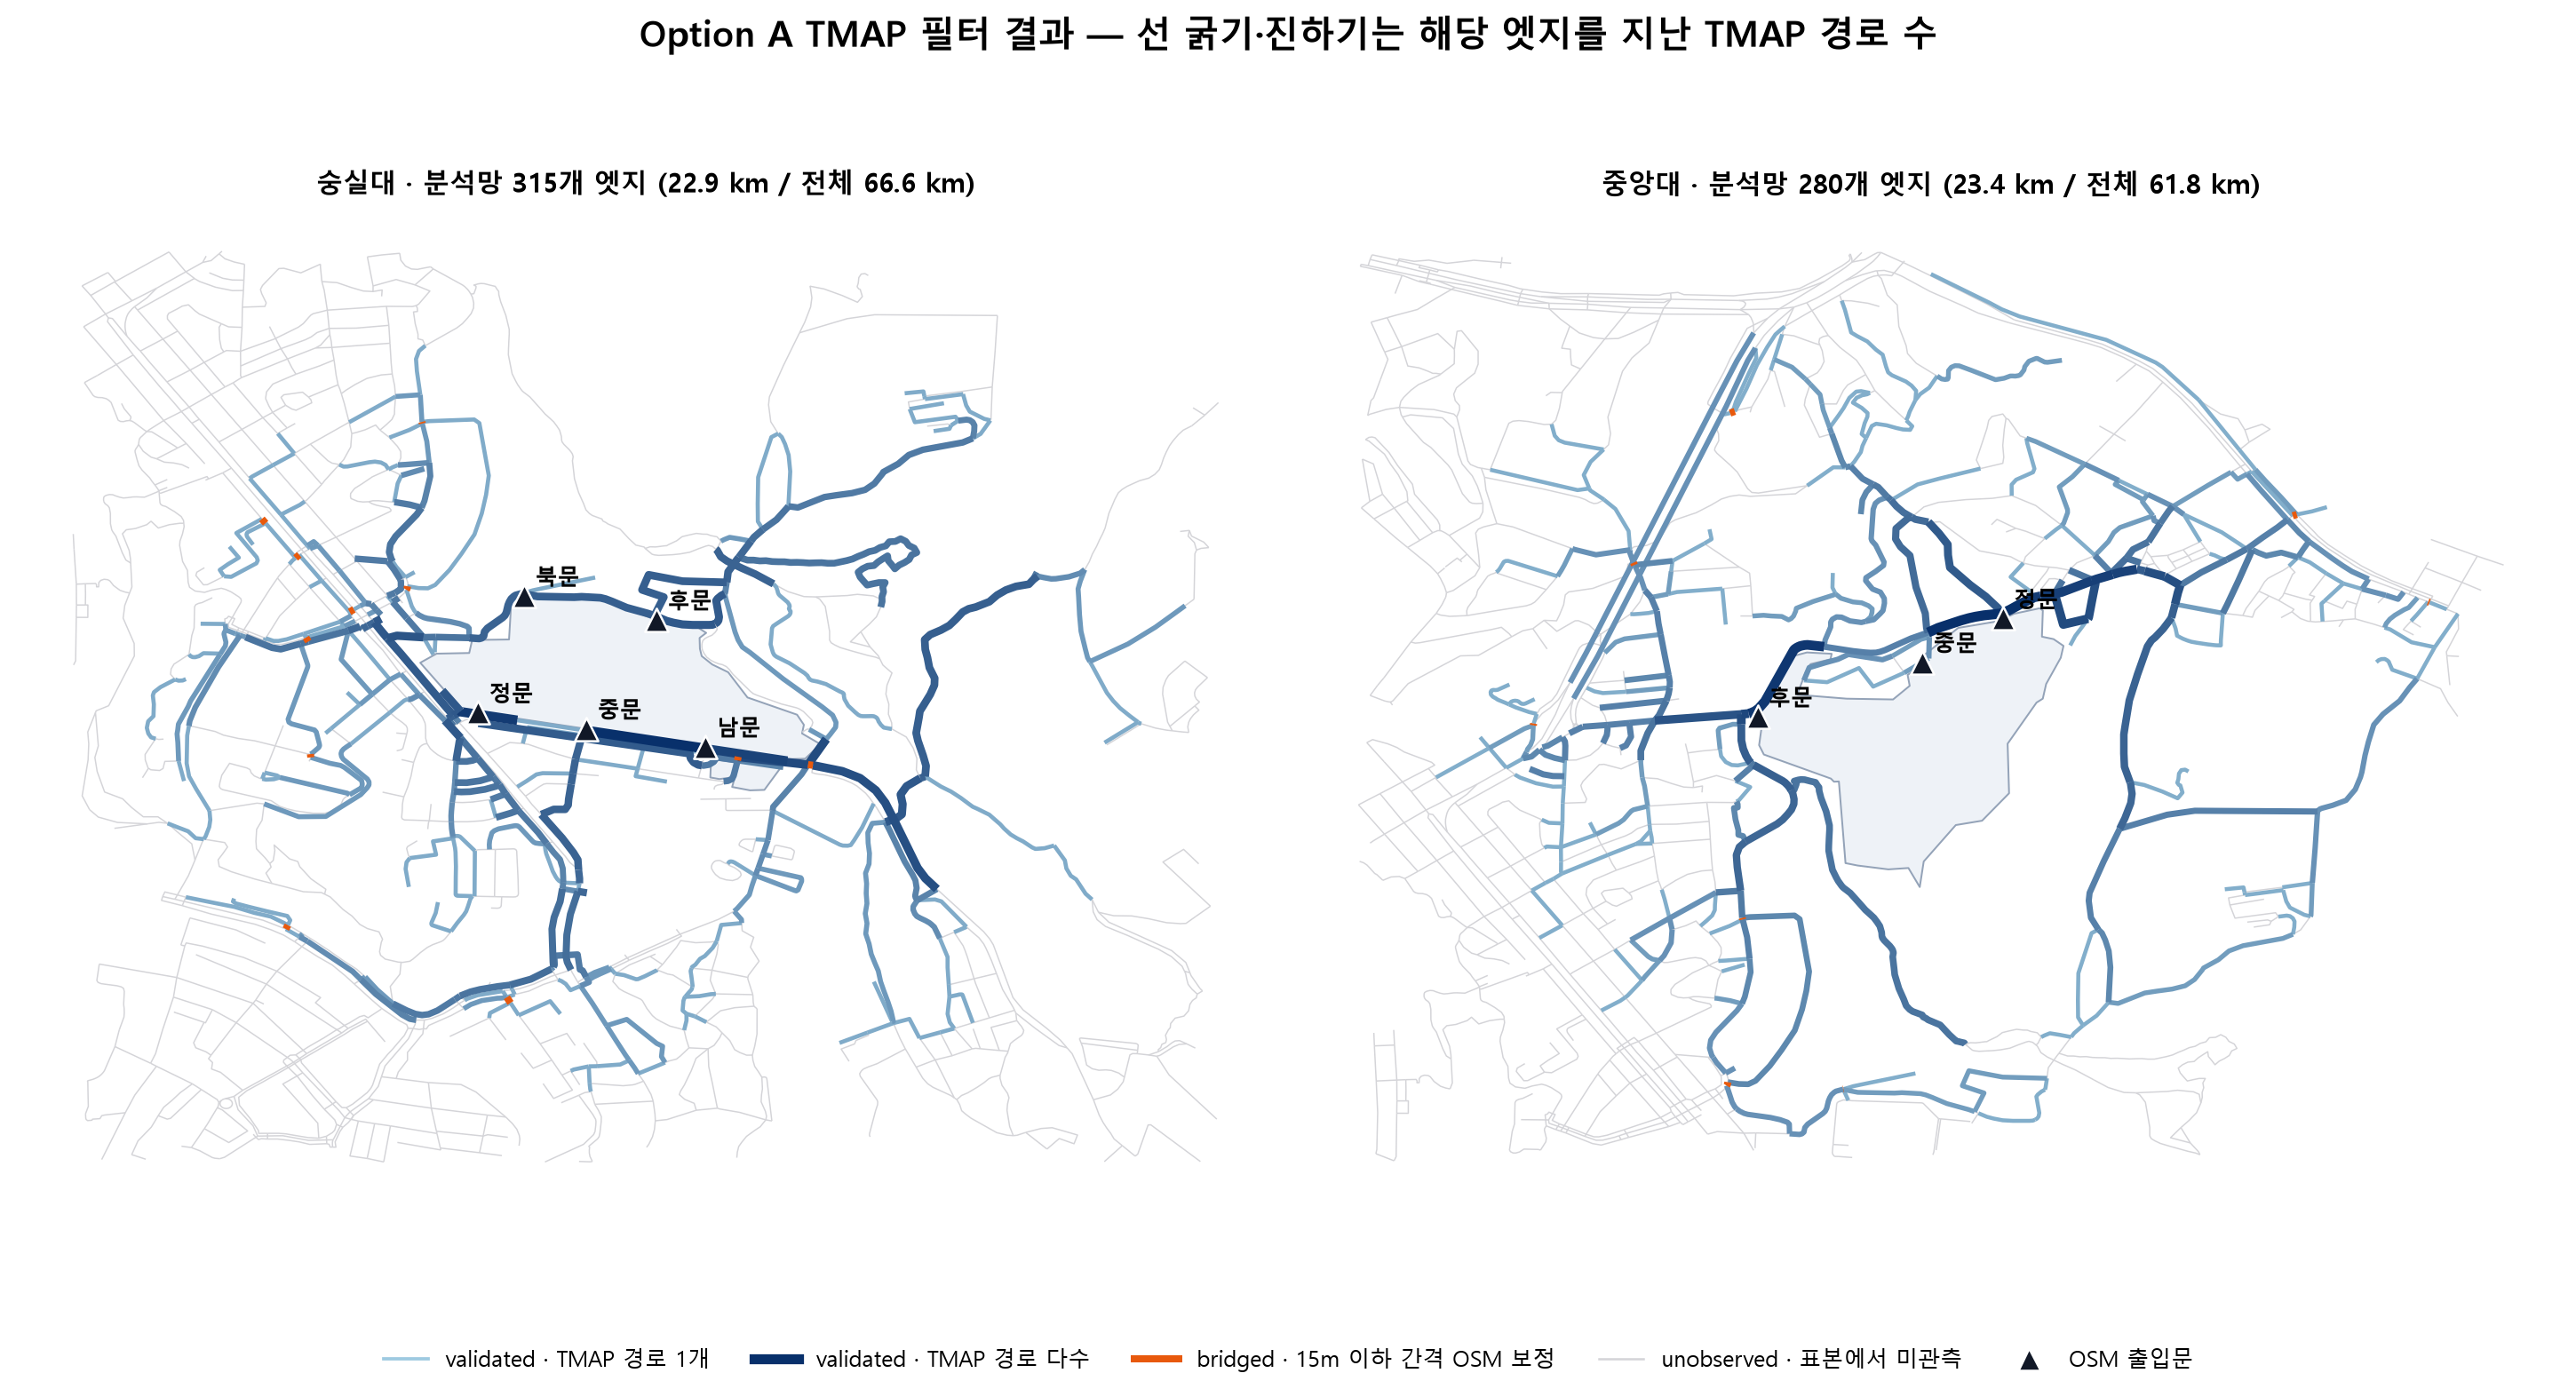

In [4]:
display(Image(filename='figures/option_a/option_a_tmap_validated_edges.png'))

## F-3. 해석 시 주의

- `unobserved`는 153개 표본 경로에 나타나지 않았다는 뜻일 뿐 보행 불가를 뜻하지 않는다.
- 매칭은 표본점마다 20m 안의 최근접 엣지 하나를 쓰므로, 교차로에서 옆 골목의 짧은 구간이 경로 1개로 validated될 수 있다(지도에서 본선 옆 짧은 가지). 경로 1개만 지난 엣지는 숭실대 137개, 중앙대 117개다.
- 문과 거의 붙은 출발지 3개(숭실대)는 1–6m 경로라 정보가 거의 없다.
- TMAP 거리/OSM 문까지 거리 비율은 중앙값 1.05이며, 6개 경로는 0.67–1.5 밖이다.
